# CS156: Pipeline - Final Draft

**Can You Diagnose Autism From Brain Noise?**

There’s a persistent idea in computational neuroscience that you can look at a brain scan and read *something* meaningful: a diagnosis, a trait, or a difference in how someone thinks. It’s a compelling idea. It’s also, at best, an approximation.

This project starts from a deliberately uncomfortable question:

> If you take a noisy, indirect measurement of brain activity and reduce it to correlations between ~200 regions, is there actually enough signal left to distinguish individuals with Autism Spectrum Disorder (ASD) from controls?

The data used here are resting-state fMRI time series, summarized as functional connectivity matrices. In practice, this means:

- we are not observing neural activity directly  
- we are not measuring interactions between regions  
- we are measuring statistical co-variation under a long chain of preprocessing assumptions  

So the object we feed into our models is already several steps removed from anything we might confidently call “brain function.”

Given that, the goal of this project is not to build a diagnostic tool, but rather to understand how different modeling assumptions interact with this highly preprocessed representation.

## The Central Puzzle
Each subject is represented as a connectivity matrix derived from ROI time series (rois_cc200). A natural modeling hypothesis is:

> $H_1$: Graph-based models should outperform matrix-based models because brain connectivity has inherent relational structure that graph architectures can exploit.

To test this, we compare four approaches:

- **Logistic Regression** on flattened connectivity features
- **Multilayer Perceptron (MLP)** on the same representation
- **Graph Convolutional Network (GCN)** that assumes connectivity topology matters
- **Graph Attention Network (GAT)** that learns which connections to emphasize

Initial results contradicted $H_1$: Logistic Regression achieved 0.72 ROC-AUC, while GCN and GAT achieved only 0.68 and 0.63 respectively. This suggests either:

1. The graph hypothesis is wrong for this task
2. Graph representations are losing information
3. Models are exploiting artifacts rather than biological signal

## Diagnostic Hypotheses
Rather than accept this result at face value, we investigate three competing explanations:

$H_2$ **(Artifact Hypothesis)**: Models are exploiting global distributional differences between groups rather than meaningful connectivity patterns.
→ Test: Compare global FC statistics between groups; ablate per-subject mean normalization.

$H_3$ **(Representation Hypothesis)**: Fisher z-transformation or graph sparsification discards task-relevant signal.
→ Test: Compare raw vs. transformed correlations; vary graph construction strategies (top-k, threshold, weighted edges).

$H_4$ **(Oversmoothing Hypothesis)**: Graph models blur connectivity values through message passing, reducing their ability to exploit discriminative extreme values.
→ Test: Compare 1-layer vs. 2-layer GCN; analyze feature importance to identify if extreme values drive classification.

$H_5$ **(Site Confound Hypothesis)**: Models generalize to novel subjects but not to novel scanning sites, suggesting site-specific artifacts dominate biological signal.
→ Test: Implement site-holdout validation where entire sites are reserved for testing.

## Experimental Design
The notebook proceeds as follows:

1. Data verification and site analysis
2. Site-stratified train/test split ($H_5$ test)
3. Baseline model training under both splits
4. Artifact diagnostics ($H_2$): distribution analysis, normalization ablation
5. Representation ablations ($H_3$): Fisher z vs. raw correlation, graph construction variants
6. Architecture analysis ($H_4$): GNN depth, feature importance
7. Comparative evaluation and hypothesis assessment

Each hypothesis generates testable predictions. For example:

- If $H_2$ is true, per-subject normalization should substantially hurt performance
- If $H_3$ is true, alternative representations should close the performance gap
- If $H_4$ is true, shallower GNNs or weighted graphs should improve over current baselines
- If $H_5$ is true, site-holdout performance should degrade relative to random splits

## What We Find

Under site-holdout evaluation (test sites: UM_1 + YALE, withheld entirely from training):

| Model | Test AUC | Test Accuracy |
|-------|----------|---------------|
| Logistic Regression | **0.800** | 0.722 |
| MLP | 0.775 | 0.728 |
| GCN | 0.772 | 0.691 |
| GAT | 0.724 | 0.660 |

$H_1$ is refuted: graph models do not outperform matrix models. Systematic ablations show this cannot be explained by artifact exploitation ($H_2$ refuted), preprocessing choices ($H_3$, $H_5$ refuted). The dominant explanation is oversmoothing ($H_4$ supported): diagnostic signal is concentrated in specific ROI-pair connections, and graph neighborhood aggregation degrades this sparse, edge-specific structure.


The aim is not to prove that functional connectivity can diagnose ASD, but to systematically diagnose why one modeling approach outperforms another—and to separate genuine signal from methodological artifacts.


# Training Setup and Utilities

## CPU Optimization
- **Thread limit:** OMP=4, MKL=4, PyTorch=4 — leaves cores free for other apps
- **Process priority:** nice=10 (below normal on macOS) — system stays responsive for Docs/Meet

## Checkpoints
Saved to `checkpoints/` after: baseline training, artifact analysis, Fisher z, graph ablations, oversmoothing.


In [19]:
import os, pickle, time
from datetime import datetime
from pathlib import Path

# ── CPU thread limiting — keeps machine responsive during run ──
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"

import torch
torch.set_num_threads(4)

try:
    import psutil
    psutil.Process(os.getpid()).nice(10)
    _nice_status = "nice=10 (below normal)"
except ImportError:
    _nice_status = "psutil not installed (run: pip install psutil)"

# ── Checkpoint + logging helpers ────────────────────────────────────────────
PARCELLATION   = "cc200"
N_ROIS         = 200
BASE_DIR       = Path("data") / "abide_fmri"
PARC_DIR       = BASE_DIR / PARCELLATION
OUTPUT_DIR     = Path("output") / PARCELLATION
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

def save_checkpoint(name: str, data) -> None:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    path = CHECKPOINT_DIR / f"{name}_{ts}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    log(f"Checkpoint saved → {path.name}")

def log(msg: str) -> None:
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}] {msg}", flush=True)

# ── Runtime tracking ─────────────────────────────────────────────────────────
pipeline_start_time = time.time()

# ── Confirmation ─────────────────────────────────────────────────────────────
log("=" * 55)
log("Overnight run — CPU optimization active")
log(f"  OMP_NUM_THREADS   = {os.environ['OMP_NUM_THREADS']}")
log(f"  MKL_NUM_THREADS   = {os.environ['MKL_NUM_THREADS']}")
log(f"  torch num_threads = {torch.get_num_threads()}")
log(f"  process priority: {_nice_status}")
log(f"  output dir:       {OUTPUT_DIR.resolve()}")
log(f"  checkpoint dir:   {CHECKPOINT_DIR.resolve()}")
log("=" * 55)


[17:47:08] =======================================================
[17:47:08] Overnight run — CPU optimization active
[17:47:08]   OMP_NUM_THREADS   = 4
[17:47:08]   MKL_NUM_THREADS   = 4
[17:47:08]   torch num_threads = 4
[17:47:08]   process priority: nice=10 (below normal)
[17:47:08]   checkpoint dir:   /Users/suiseinakagawa/Desktop/University/Academics/3rd year/Spring 2026/CS156/assignments/abide-graph-classifier/data/abide_fmri/cc200/checkpoints
[17:47:08] =======================================================


# Data

The dataset is derived from the ABIDE preprocessed repository (FCP-INDI), using derivatives generated by the CPAC pipeline with the `filt_global` preprocessing strategy and the CC200 functional parcellation. Each subject is represented by ROI-level time series extracted from resting-state fMRI data.

Subjects are included based on:

- Valid phenotypic entry (`FILE_ID != "no_filename"`)
- Diagnostic label restricted to ASD and control groups (`DX_GROUP in {1, 2}`)
- Availability of corresponding CC200 time series files

Subjects with missing files, invalid dimensions, or failed loading are excluded. The final dataset contains 1035 subjects, split into training (828) and test (207) sets using stratified sampling over diagnosis labels.


## Preprocessing and CC200 representation

All imaging data are derived from the ABIDE Preprocessed derivatives hosted on the FCP-INDI Amazon S3 bucket. We specifically use:

- Pipeline: C-PAC (`cpac`)
- Strategy: global signal regression with band-pass filtering (`filt_global`)
- Derivative: CC200 ROI time series (`rois_cc200`)

Each subject is identified by a unique `FILE_ID`, which is used to retrieve precomputed ROI time series stored as `.1D` files.

The input to our models consists of precomputed ROI time series extracted using the Craddock 200 (CC200) functional parcellation. Each subject’s data is represented as a matrix:

$$
[
X \in \mathbb{R}^{T \times 200}
]
$$

where rows correspond to time points and columns correspond to ROIs.

Time series orientation is standardized such that inputs are reshaped to $T \times 200$ if required. No additional temporal preprocessing (e.g., trimming of initial volumes or additional filtering) is applied beyond the ABIDE-provided derivatives.

No additional per-ROI normalization or z-scoring is performed prior to connectivity estimation.


# Feature Construction

Functional Connectivity (FC) is computed per subject as the pairwise Pearson correlation between all ROI time series, producing a symmetric connectivity matrix:

$$
[
\text{FC}_{ij} = \mathrm{corr}(X_i, X_j)
]
$$ 

To stabilize variance and improve statistical properties, FC matrices are transformed using the Fisher z-transform:

$$
[
Z = \operatorname{arctanh}(R)
]
$$

Prior to transformation, correlation values are clipped to $(-1 + \epsilon, 1 - \epsilon)$ to ensure numerical stability. After transformation:

- NaN and infinite values are replaced with zero
- Diagonal entries are set to zero

The resulting Fisher z-transformed FC matrix serves as the shared representation for all downstream models.


## Matrix Representation

Each FC matrix is vectorized by extracting the upper triangular portion (excluding the diagonal), yielding a feature vector of size:

$$
[
\frac{200 \cdot 199}{2} = 19{,}900
]
$$

These features are standardized using z-score normalization (fit on training data only).

This representation is used for classical machine learning models (Logistic Regression and MLP).

## Graph Representation

Each subject is represented as a graph constructed from its FC matrix.

### Graph construction
- Nodes correspond to ROIs (200 total)
- For each node, edges are formed to the top $k = 10$ ROIs with highest absolute FC magnitude
- Edge selection is based on connectivity strength $|Z_{ij}|$
- The graph is symmetrized to form an undirected structure
- Self-loops are excluded

This produces a sparse k-nearest-neighbor graph over functional connectivity structure.

### Edge definition
Edges encode connectivity structure only and are treated as unweighted. Correlation values are not used as edge weights during message passing.


### Node features

Each node is represented by its corresponding FC connectivity profile:

$$
[
x_i = Z_{i,:}
]
$$

i.e., the $i$-th row of the Fisher z-transformed FC matrix.

Node features are normalized per node using z-score normalization:

$$
[
x_i \leftarrow \frac{x_i - \mu_i}{\sigma_i}
]
$$

where $\mu_i$ and $\sigma_i$ are the mean and standard deviation of the $i$-th node’s feature vector. This representation introduces some redundancy between node features and graph structure, as both are derived from the same connectivity matrix. However, the graph structure is derived heuristically from correlation magnitude rather than known anatomical connectivity, which may limit the effectiveness of graph-based inductive biases. 

## Key methodological notes

- Fisher z-transform is applied consistently across all representations
- Graph topology is determined by connectivity magnitude, not sign
- GNN models operate on unweighted graphs, with structure derived from FC
- Both ML and GNN models are based on the same underlying FC representation
- No dimensionality reduction (e.g., PCA) is applied
- No additional temporal preprocessing is performed beyond ABIDE derivatives

In [ ]:
# Load time-series data and compute Fisher z-transformed functional connectivity matrices
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

base_dir = PARC_DIR
ts_dir = base_dir / "timeseries"
fc_dir = base_dir / "connectivity_matrices"

print("[INIT] Ensuring output directory exists...")
fc_dir.mkdir(parents=True, exist_ok=True)

subjects_path = BASE_DIR / "subjects_clean.csv"

def fisher_z_transform(corr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Apply Fisher z-transform safely to correlation matrix."""
    clipped = np.clip(corr, -1 + eps, 1 - eps)
    return np.arctanh(clipped)

# Step 1: Load subject list from CSV or filesystem
print("[STEP 1] Getting subject list...")

if subjects_path.exists():
    print("  -> Reading CSV")
    subjects_df = pd.read_csv(subjects_path)
    print("  -> CSV loaded")

    file_ids = subjects_df["FILE_ID"].dropna().astype(str).drop_duplicates().tolist()
    print("  -> Extracted FILE_IDs")
else:
    print("  -> No CSV found, scanning timeseries folder")
    file_ids = sorted(p.stem for p in ts_dir.glob("*.1D"))

print(f"[STEP 1 DONE] {len(file_ids)} subjects")

valid_ids = []
failed_ids = []
skipped_ids = []
roi_count = None

# Step 2: Process each subject's time series and compute functional connectivity
print("[STEP 2] Starting processing loop...")

for i, fid in enumerate(tqdm(file_ids, desc="Processing")):
    ts_path = ts_dir / f"{fid}.1D"
    fc_path = fc_dir / f"{fid}.npy"

    # Skip subjects whose connectivity matrices already exist
    if fc_path.exists():
        skipped_ids.append(fid)
        valid_ids.append(fid)
        continue

    if not ts_path.exists():
        print(f"[WARN] Missing file: {fid}")
        failed_ids.append(fid)
        continue

    try:
        ts = np.loadtxt(ts_path)

        if ts.ndim != 2:
            print(f"[WARN] Bad shape (ndim) for {fid}: {ts.ndim}")
            failed_ids.append(fid)
            continue

        # Ensure time series is (time_points, N_ROIS) format
        if ts.shape[1] == N_ROIS:
            pass
        elif ts.shape[0] == N_ROIS:
            ts = ts.T
            print(f"[INFO] Transposed: {fid}")
        else:
            print(f"[WARN] Unexpected shape for {fid}: {ts.shape}")
            failed_ids.append(fid)
            continue

        # Compute Pearson correlation between ROI time series
        corr = np.corrcoef(ts, rowvar=False)

        # Apply Fisher z-transform immediately after correlation computation
        z = fisher_z_transform(corr)
        z = np.nan_to_num(z).astype(np.float32)  # Replace NaN/inf with 0 and convert to float32
        np.fill_diagonal(z, 0)  # Remove self-loops

        if roi_count is None:
            roi_count = z.shape[0]
            print(f"[INFO] ROI count set to {roi_count}")

        if z.shape != (roi_count, roi_count):
            print(f"[WARN] Shape mismatch for {fid}: {z.shape}")
            failed_ids.append(fid)
            continue

        np.save(fc_path, z)
        valid_ids.append(fid)

    except Exception as e:
        print(f"[ERROR] Failed {fid}: {e}")
        failed_ids.append(fid)

print("[STEP 2 DONE] Processing finished")

# Step 3: Create index file linking FILE_IDs to their connectivity matrices and labels
print("[STEP 3] Building index...")

index_df = pd.DataFrame({"FILE_ID": valid_ids})

if subjects_path.exists():
    subjects_clean = subjects_df[subjects_df["FILE_ID"].isin(valid_ids)].copy()

    index_df = index_df.merge(
        subjects_clean[["FILE_ID", "DX_GROUP"]],
        on="FILE_ID",
        how="left"
    )

index_df.to_csv(base_dir / "connectivity_index.csv", index=False)

# Summary of processing results
print("\n--- Summary ---")
print(f"Processed new: {len(valid_ids) - len(skipped_ids)}")
print(f"Skipped: {len(skipped_ids)}")
print(f"Failed: {len(failed_ids)}")

if roi_count is not None:
    print(f"Matrix shape: ({roi_count}, {roi_count})")

if failed_ids:
    print("Example failures:", failed_ids[:10])

In [ ]:
# Convert Fisher z-transformed connectivity matrices to sparse PyG graph objects with unweighted top-k edge selection
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
from torch_geometric.data import Data

base_dir = PARC_DIR
fc_dir = base_dir / "connectivity_matrices"
index_path = base_dir / "connectivity_index.csv"
pyg_dir = base_dir / "pyg"
pyg_dir.mkdir(parents=True, exist_ok=True)

TOP_K = 10

def matrix_to_topk_edge_index(adj: np.ndarray, k: int = 10):
    """Extract unweighted top-k edges per node from adjacency matrix.
    Keeps symmetric edges (undirected graph); self-loops removed.
    Returns edge_index (2 x num_edges).
    """
    n = adj.shape[0]
    a = adj.copy().astype(np.float32)
    np.fill_diagonal(a, 0.0)

    edges = set()
    for i in range(n):
        row = a[i]

        # Select top-k neighbors by absolute connectivity magnitude for this node
        valid_idx = np.where(np.abs(row) > 0)[0]
        if len(valid_idx) >= k:
            idx = valid_idx[np.argsort(np.abs(row[valid_idx]))[-k:]]
        else:
            idx = valid_idx

        for j in idx:
            if i == j:
                continue
            u, v = sorted((i, j))
            edges.add((u, v))

    if not edges:
        return torch.empty((2, 0), dtype=torch.long)

    edge_list = []

    # Add bidirectional edges for undirected graph representation
    for (u, v) in edges:
        edge_list.append([u, v])
        edge_list.append([v, u])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Load subject index and build graph objects
index_df = pd.read_csv(index_path)
label_map = {1: 1, 2: 0}  # DX_GROUP: 1=ASD -> 1, 2=Control -> 0

graphs = []
skipped = []

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Building graphs"):
    fid = str(row["FILE_ID"])
    y_raw = row.get("DX_GROUP", np.nan)

    mat_path = fc_dir / f"{fid}.npy"
    if not mat_path.exists():
        skipped.append(fid)
        continue

    # Matrices are already Fisher z-transformed in the FC construction cell.
    adj = np.load(mat_path)

    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        skipped.append(fid)
        continue

    adj = np.nan_to_num(adj).astype(np.float32)
    np.fill_diagonal(adj, 0.0)

    # Unweighted sparse structure via top-k selection.
    edge_index = matrix_to_topk_edge_index(adj, k=TOP_K)
    assert edge_index.max() < adj.shape[0]

    # Node features: full connectivity profile (200-dim vector per ROI, normalized)
    x = torch.tensor(adj, dtype=torch.float32)
    x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
    assert x.shape == (adj.shape[0], adj.shape[1])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=None,
        file_id=fid
    )

    if pd.notna(y_raw):
        data.y = torch.tensor([label_map[int(y_raw)]], dtype=torch.long)

    graphs.append(data)

# Save graph list to disk
out_path = pyg_dir / f"graphs_top{TOP_K}.pt"
torch.save(graphs, out_path)

print(f"Saved {len(graphs)} graphs -> {out_path}")
print(f"Skipped: {len(skipped)}")

if graphs:
    g = graphs[0]
    print(f"Graph sanity: nodes={g.num_nodes}, edges={g.edge_index.shape[1]}, unweighted graph used")

# Splitting the Data

## Site-Holdout Split Strategy

**Hypothesis $H_5$ (Site Confound)** posits that models may be learning site-specific scanner artifacts or preprocessing signatures rather than biological signal. To test this, we implement a **site-holdout evaluation** where entire sites are reserved for testing, ensuring the model has never seen data from those scanners during training.

| Role | Sites | N | ASD | Control | ASD% |
|------|-------|---|-----|---------|------|
| **Test** | UM_1, YALE | 162 | 81 | 81 | 50.0% |
| **Train** | 18 remaining sites | 873 | — | — | — |

### Comparison to Original Split

The original random 80/20 split (828 train / 207 test) was **diagnosis-stratified but not site-stratified**, meaning both training and test sets contained subjects from all 20 sites. Under this scheme, the model was always evaluated on subjects from sites it had encountered during training, potentially learning:

- Site-specific scanner characteristics (field strength, acquisition parameters)
- Site-specific preprocessing artifacts (motion correction, registration quality)
- Site-specific demographic confounds (age, sex, medication status)

### Prediction Under $H_5$

If site effects dominate biological signal, we predict:

- Site-holdout AUC < Random-split AUC (performance degrades when generalizing to truly novel sites)
- Models with higher capacity (MLP, GNNs) may show larger degradation if they overfit to site-specific patterns
- Simpler models (Logistic Regression) may be more robust if they rely on stable, site-invariant features

### Holdout Site Selection Rationale

**UM_1** (n=106, 50% ASD): Largest perfectly-balanced site; provides a strong generalization stress test with sufficient power.

**YALE** (n=56, 50% ASD): Independently balanced; combining with UM_1 yields a 162-subject test set with exact 50/50 class balance, matching the training distribution.

Together, these sites provide:

- Geographic diversity (University of Michigan vs. Yale)
- Sufficient test sample size (~15% of total dataset)
- Perfect diagnostic balance (eliminates class imbalance as a confound)

**Interpretation:** If models maintain performance under site-holdout, this provides evidence against $H_5$ and suggests the learned features generalize beyond site-specific artifacts. If performance degrades substantially, this supports $H_5$ and indicates that apparent diagnostic signal may partly reflect site confounds.

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch

base = PARC_DIR
mat_dir = base / "connectivity_matrices"
graph_path = base / "pyg" / "graphs_top10.pt"
pheno_path = Path("data/Phenotypic_V1_0b_preprocessed1.csv")

# Load phenotypic data; keep only subjects that have FC matrices on disk
pheno = pd.read_csv(pheno_path)
matrix_ids = {p.stem for p in mat_dir.glob("*.npy")}
pheno = pheno[pheno["FILE_ID"].isin(matrix_ids)].copy()
pheno["FILE_ID"] = pheno["FILE_ID"].astype(str)

# Site summary
site_stats = (
    pheno.groupby("SITE_ID")
    .agg(n=("SUB_ID", "count"),
         n_asd=("DX_GROUP", lambda x: (x == 1).sum()),
         n_ctrl=("DX_GROUP", lambda x: (x == 2).sum()))
    .assign(asd_pct=lambda d: (d["n_asd"] / d["n"] * 100).round(1))
    .sort_values("n", ascending=False)
)
print("=== Site Summary (subjects with FC matrices) ===")
print(site_stats.to_string())
print(f"\nTotal: {len(pheno)} subjects across {pheno['SITE_ID'].nunique()} sites")

# Define holdout
TEST_SITES  = ["UM_1", "YALE"]
TRAIN_SITES = sorted(s for s in pheno["SITE_ID"].unique() if s not in TEST_SITES)

# Build split manifest
split_df = pheno[["FILE_ID", "DX_GROUP", "SITE_ID"]].copy()
split_df["split"] = split_df["SITE_ID"].apply(lambda s: "test" if s in TEST_SITES else "train")

# Verify no site overlap
_train_sites = set(split_df[split_df["split"] == "train"]["SITE_ID"])
_test_sites  = set(split_df[split_df["split"] == "test"]["SITE_ID"])
assert _train_sites & _test_sites == set(), "Site overlap detected!"
print(f"\n\u2713 No site overlap (train: {len(_train_sites)} sites, test: {len(_test_sites)} sites)")

print("\n=== Split Sizes ===")
print(split_df["split"].value_counts().to_string())
print("\nClass counts by split (1=ASD, 2=Control):")
print(pd.crosstab(split_df["split"], split_df["DX_GROUP"]))
print("\nTest site breakdown:")
print(
    split_df[split_df["split"] == "test"]
    .groupby("SITE_ID")
    .agg(n=("FILE_ID", "count"),
         asd=("DX_GROUP", lambda x: (x == 1).sum()),
         ctrl=("DX_GROUP", lambda x: (x == 2).sum()))
    .to_string()
)

# Save manifests
split_df.to_csv(BASE_DIR / "subject_split_site_holdout.csv", index=False)
split_df[split_df["split"] == "train"].to_csv(BASE_DIR / "train_subjects_site_holdout.csv", index=False)
split_df[split_df["split"] == "test"].to_csv(BASE_DIR / "test_subjects_site_holdout.csv", index=False)

# Split graph objects
if not graph_path.exists():
    raise FileNotFoundError(f"Missing {graph_path}. Re-run the graph-construction cell first.")

graphs = torch.load(graph_path, weights_only=False)
graph_by_id = {}
for g in graphs:
    gid = getattr(g, "file_id", None) or getattr(g, "fid", None)
    if gid is not None:
        graph_by_id[str(gid)] = g

train_ids = set(split_df[split_df["split"] == "train"]["FILE_ID"])
test_ids  = set(split_df[split_df["split"] == "test"]["FILE_ID"])

train_graphs = [graph_by_id[fid] for fid in sorted(train_ids) if fid in graph_by_id]
test_graphs  = [graph_by_id[fid] for fid in sorted(test_ids)  if fid in graph_by_id]

torch.save(train_graphs, base / "pyg" / "graphs_top10_train.pt")
torch.save(test_graphs,  base / "pyg" / "graphs_top10_test.pt")

print(f"\nSaved manifests to {BASE_DIR}.")
print(f"Train: {len(train_graphs)} graphs | Test: {len(test_graphs)} graphs")


# Exploratory Data Analysis

To validate the data and illustrate the representations used in downstream models, we perform a small set of sanity-check analyses.

### Functional connectivity representation

An example subject-level functional connectivity matrix (Fisher z-transformed) is shown below. Each matrix is high-dimensional (200 $\times$ 200), making direct visual interpretation limited, but it encodes pairwise relationships between brain regions and serves as the input for downstream modeling.

### Graph representation

The corresponding graph representation for a single subject is also shown. Nodes correspond to regions of interest (ROIs), and edges represent the top-k strongest pairwise functional connections under a magnitude-based sparsification rule selected via a top-k sparsification step. This produces a sparse graph structure that can be used with graph neural networks.

### Distribution of connectivity values

The distribution of Fisher z-transformed connectivity values across a subsample of subjects is centered near zero and bounded, consistent with the stabilizing effect of the Fisher transformation on correlation coefficients. This indicates that the data is numerically well-conditioned for modeling.

### Class-level connectivity patterns

Average functional connectivity matrices are computed separately for ASD and control groups using a subsample of subjects from each class. Visual comparison suggests potential differences in large-scale connectivity structure between groups, but this is purely descriptive and not a statistical test. These patterns motivate the use of supervised models to learn discriminative representations between classes.

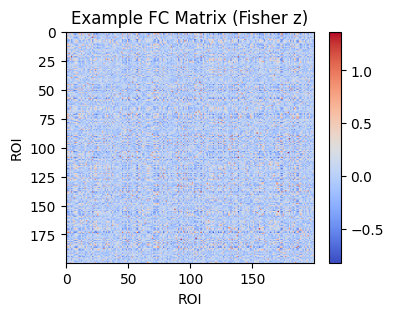

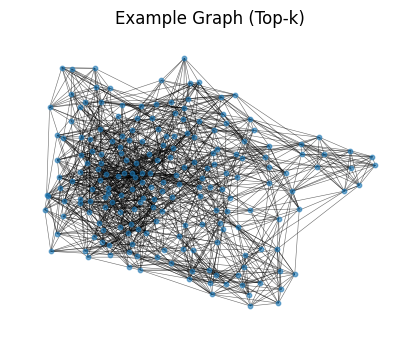

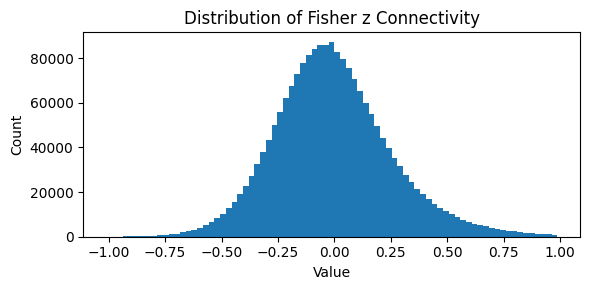

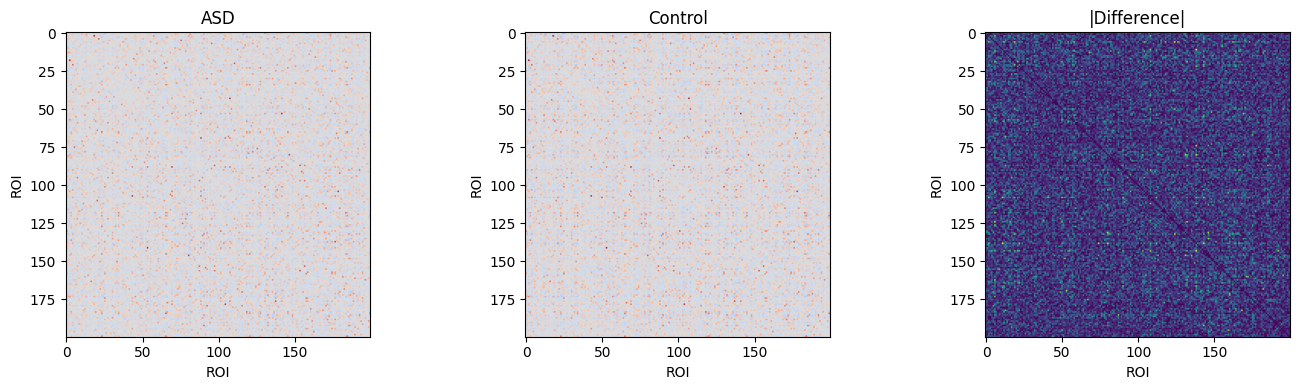

{'example_subject': 'UM_2_0050382',
 'graph_stats': {'num_graphs': 1035,
  'nodes_unique': [200],
  'edges_mean': 1348.6444444444444,
  'edges_std': 58.483204208129806,
  'edges_min': 537,
  'edges_max': 1553}}

In [21]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# Paths
base = PARC_DIR
fc_dir = base / "connectivity_matrices"
index_path = base / "connectivity_index.csv"
graph_path = base / "pyg" / "graphs_top10.pt"

# Load metadata
index_df = pd.read_csv(index_path)
index_df = index_df[index_df["DX_GROUP"].isin([1, 2])].copy()
index_df["FILE_ID"] = index_df["FILE_ID"].astype(str)
index_df = index_df[index_df["FILE_ID"].apply(lambda fid: (fc_dir / f"{fid}.npy").exists())]

graphs = torch.load(graph_path, weights_only=False)

# -----------------------------
# 1) Example FC matrix
# -----------------------------
example_fid = index_df.sample(1, random_state=42)["FILE_ID"].iloc[0]

fc = np.load(fc_dir / f"{example_fid}.npy", mmap_mode="r")
fc = np.nan_to_num(fc).astype(np.float32)
np.fill_diagonal(fc, 0)

plt.figure(figsize=(4, 3))
plt.imshow(fc, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Example FC Matrix (Fisher z)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.show()

# -----------------------------
# 2) Example graph
# -----------------------------
graph_map = {str(getattr(g, "file_id", "")): g for g in graphs}
g = graph_map.get(example_fid, graphs[0])

edge_index = g.edge_index.cpu().numpy()

G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
G.add_edges_from(edge_index.T.tolist())

plt.figure(figsize=(4, 3))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, width=0.4, alpha=0.6)
plt.title("Example Graph (Top-k)")
plt.axis("off")
plt.show()

# -----------------------------
# 3) FC distribution (SAFE + SIMPLE)
#    -> no full concatenation, no streaming stats
# -----------------------------
sample_ids = index_df.sample(n=min(100, len(index_df)), random_state=42)["FILE_ID"]

bins = np.linspace(-1, 1, 80)
hist = np.zeros(len(bins) - 1, dtype=np.float64)

for fid in sample_ids:
    z = np.load(fc_dir / f"{fid}.npy", mmap_mode="r")
    z = np.nan_to_num(z)

    vals = z[np.triu_indices_from(z, k=1)]
    hist += np.histogram(vals, bins=bins)[0]

plt.figure(figsize=(6, 3))
plt.bar(bins[:-1], hist, width=bins[1] - bins[0])
plt.title("Distribution of Fisher z Connectivity")
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -----------------------------
# 4) Class-level means (SAFE + BALANCED SAMPLING)
# -----------------------------

def mean_fc(ids, max_n=25):
    ids = list(ids)
    ids = ids[:max_n]  # cap per class for stability

    acc = None
    count = 0

    for fid in ids:
        z = np.load(fc_dir / f"{fid}.npy", mmap_mode="r")
        z = np.nan_to_num(z)
        np.fill_diagonal(z, 0)

        if acc is None:
            acc = np.zeros_like(z, dtype=np.float32)

        acc += z.astype(np.float32)
        count += 1

    return acc / max(count, 1)


# balanced sampling from each class (important fix)
asd_pool = index_df[index_df["DX_GROUP"] == 1]["FILE_ID"]
ctl_pool = index_df[index_df["DX_GROUP"] == 2]["FILE_ID"]

asd_ids = asd_pool.sample(n=min(25, len(asd_pool)), random_state=42)
ctl_ids = ctl_pool.sample(n=min(25, len(ctl_pool)), random_state=42)

mean_asd = mean_fc(asd_ids)
mean_ctl = mean_fc(ctl_ids)
diff = np.abs(mean_asd - mean_ctl)

vmax = np.max(np.abs([mean_asd, mean_ctl]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(mean_asd, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("ASD")

axes[1].imshow(mean_ctl, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Control")

axes[2].imshow(diff, cmap="viridis")
axes[2].set_title("|Difference|")

for ax in axes:
    ax.set_xlabel("ROI")
    ax.set_ylabel("ROI")

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Graph stats
# -----------------------------
node_counts = [g.num_nodes for g in graphs]
edge_counts = [g.edge_index.shape[1] // 2 for g in graphs]

graph_stats = {
    "num_graphs": len(graphs),
    "nodes_unique": sorted(set(node_counts)),
    "edges_mean": float(np.mean(edge_counts)),
    "edges_std": float(np.std(edge_counts)),
    "edges_min": int(np.min(edge_counts)),
    "edges_max": int(np.max(edge_counts)),
}

eda_summary = {
    "example_subject": example_fid,
    "graph_stats": graph_stats,
}

eda_summary

# Model Descriptions

## Training Objective

All models are trained as binary classifiers, but the optimization objective differs by model family.

For matrix-based models (Logistic Regression and MLP), the training objective is binary cross-entropy (BCE). Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$ with labels $y_i \in \{0,1\}$ and predicted probabilities $\hat{y}_i \in (0,1)$, the loss is defined as:
$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

This objective encourages the model to assign high probability to the correct class and penalizes confident incorrect predictions.

For graph models (GCN and GAT), training uses 2-class logits with cross-entropy loss (implemented as `CrossEntropyLoss`) and softmax probabilities at inference time.

## Functions and Notation

We use the following standard functions to explain each model:

- **Sigmoid function**:
  $$
  \sigma(z) = \frac{1}{1 + e^{-z}}
  $$
  Maps a real-valued input to a probability in $(0,1)$.

- **ReLU (Rectified Linear Unit)**:
  $$
  \text{ReLU}(z) = \max(0, z)
  $$

- **LeakyReLU** (used in GAT attention):
  $$
  \text{LeakyReLU}(z) =
  \begin{cases}
  z & \text{if } z \geq 0 \\
  \alpha z & \text{if } z < 0
  \end{cases}
  $$
  where $\alpha$ is a small constant.

- **tanh (hyperbolic tangent)**:
  $$
  \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
  $$
  Maps inputs to the range $(-1, 1)$ and is zero-centered.

- **Nonlinear activation $\phi(\cdot)$**:

  Denotes an element-wise nonlinearity. In practice, this is instantiated as ReLU or tanh for MLPs, ReLU for GCN, and ELU for GAT.

- **Indicator function**:
  $$
  \mathbb{I}[\cdot]
  $$
  evaluates to 1 if the condition is true and 0 otherwise.

## Models Trained on the Matrix Representation

Each subject is represented by the upper triangular entries of the Fisher z-transformed connectivity matrix (excluding the diagonal), yielding a feature vector of size:
$$
\frac{200 \cdot 199}{2} = 19{,}900
$$

Features are standardized using z-scoring based on training data statistics.

### Logistic Regression

Logistic regression provides a linear baseline for classification on vectorized functional connectivity features.
This model learns a single global weight for each connection in the connectivity matrix and combines them linearly. Each feature contributes independently to the prediction, making the model easy to interpret but unable to capture interactions between connections.

#### Mathematical Formulation

The model estimates:
$$
P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

and is trained by minimizing binary cross-entropy loss.

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Linear score:
   $$
   z = \mathbf{w}^\top \mathbf{x} + b
   $$

2. Probability:
   $$
   \hat{y} = \sigma(z)
   $$

3. Class prediction:
   $$
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

### Multilayer Perceptron (MLP)

The MLP extends logistic regression by introducing non-linear transformations through hidden layers.
Instead of assigning a single weight per feature, the MLP learns hierarchical combinations of connections. Hidden layers allow the model to capture interactions between multiple edges, enabling more complex decision boundaries at the cost of reduced interpretability.

#### Mathematical Formulation

An $L$-layer MLP computes:
$$
\mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})
$$

with output:
$$
\hat{y} = \sigma(\mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)})
$$

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Initialize:
   $$
   \mathbf{h}^{(0)} = \mathbf{x}
   $$

2. Hidden layers (ReLU or tanh applied element-wise):
   $$
   \mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}), \quad l = 1, \dots, L-1
   $$

3. Output logits:
   $$
   z = \mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)}
   $$

4. Probability and prediction:
   $$
   \hat{y} = \sigma(z), \quad
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

## Models Trained on the Graph Representation

Each subject is represented as a graph:

- Nodes: 200 ROIs  
- Edges: top-$k$ strongest connections per node ($k = 10$)  
- Node features: each node is represented by its connectivity profile (200-dimensional)

Node features are normalized independently per node using z-score normalization across the feature dimension.

### Graph Convolutional Network (GCN)

The GCN operates directly on graph-structured functional connectivity data.
The GCN treats the brain as a graph and updates each node by averaging information from its neighbors. This enforces a locality bias: predictions depend on patterns of connectivity within neighborhoods rather than individual edges. The final graph representation summarizes these localized patterns across all nodes.

#### Mathematical Formulation

A GCN layer computes:
$$
\mathbf{H}^{(l+1)} = \phi\left( \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} \mathbf{H}^{(l)} \mathbf{W}^{(l)} \right)
$$

#### Forward Pass and Prediction

Given $\mathbf{H}^{(0)} \in \mathbb{R}^{N \times d}$:

1. First layer (ReLU applied after aggregation):
   $$
   \mathbf{H}^{(1)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(0)} \mathbf{W}^{(0)})
   $$

2. Second layer:
   $$
   \mathbf{H}^{(2)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(1)} \mathbf{W}^{(1)})
   $$

3. Global mean pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \mathbf{p} = \operatorname{softmax}(\mathbf{W}\mathbf{h}_{\text{graph}} + \mathbf{b}), \quad
   \hat{y}_{\text{class}} = \arg\max_c p_c
   $$

### Graph Attention Network (GAT)

The GAT extends GCN by learning attention weights over neighboring nodes.
Instead of treating all neighbors equally, the GAT learns to weight them based on their relevance. This allows the model to focus on the most informative connections for each node, rather than averaging indiscriminately, leading to a more flexible and adaptive notion of neighborhood structure.


#### Mathematical Formulation


Attention coefficients:

$$
\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top [\mathbf{W}\mathbf{h}_i \, \| \, \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)} \exp(\cdot)}
$$

Node updates:

$$
\mathbf{h}_i' = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}\mathbf{h}_j \right)
$$

#### Forward Pass and Prediction


Given $\{\mathbf{h}_i^{(0)}\}$:

1. First attention layer:

   $$
   \mathbf{h}_i^{(1)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}^{(0)} \mathbf{h}_j^{(0)} \right)
   $$

2. Second attention layer:
   $$
   \mathbf{h}_i^{(2)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(2)} \mathbf{W}^{(1)} \mathbf{h}_j^{(1)} \right)
   $$

3. Global pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \mathbf{p} = \operatorname{softmax}(\mathbf{W}\mathbf{h}_{\text{graph}} + \mathbf{b}), \quad
   \hat{y}_{\text{class}} = \arg\max_c p_c
   $$

# Training with Cross-Validation and Hyperparameter Tuning

Hyperparameter tuning uses 5-fold stratified cross-validation on the training set.
For matrix models (Logistic Regression, MLP), `GridSearchCV` is used. For graph models (GCN, GAT),
a manual grid search loops over all config combinations and selects the best mean CV AUC.

| Model | Grid | Configs | Epochs | Est. time |
|-------|------|---------|--------|-----------|
| LogReg | C $\in$ {0.1, 1, 10} | 3 | — | ~3 min |
| MLP | 2 hidden $\times$ 3 α | 6 | — | ~15 min |
| GCN | 3 hidden $\times$ 2 lr $\times$ 2 drop | 12 | 80 $\times$ 5 folds | ~2 hr |
| GAT | 2 hidden $\times$ 2 heads $\times$ 3 lr | 12 | 80 $\times$ 5 folds | ~3 hr |

The best config per model is retrained on the full training set for final test evaluation.


## Training Details

Neural network models (MLP, GCN, GAT) are trained using the Adam optimizer.

- **MLP**:
  - Maximum iterations: 500  
  - Early stopping enabled (validation fraction = 0.1)

- **GCN and GAT**:
  - Trained for 80 epochs  
  - GCN uses ReLU activations; GAT uses ELU activations  


## Hyperparameter Search

We perform grid search over predefined hyperparameter spaces for each model. All models are evaluated under identical cross-validation settings to ensure comparability of results.

### Logistic Regression

- Regularization type: fixed (L2)
- Solver: fixed `lbfgs`
- Regularization strength: $\{0.1, 1.0, 10.0\}$
- Class weighting: fixed (None)
- Maximum iterations: 1000


### Multilayer Perceptron (MLP)

- Hidden layer architectures: $(64)$, $(128)$
- Regularization type: fixed (L2)
- Regularization strength: $\{10^{-4}, 10^{-3}, 10^{-2}\}$
- Activation function: fixed (ReLU)  
- Learning rate: $[10^{-4}, 5 \times 10^{-4}, 10^{-3}]$  
- Maximum iterations: 500

### Graph Convolutional Network (GCN)

- Hidden dimension: $\{32, 64, 128\}$  
- Dropout: $\{0.2, 0.4\}$  
- Learning rate: $\{10^{-4}, 10^{-3}\}$  
- Weight decay: fixed ($10^{-4}$)  

### Graph Attention Network (GAT)

Due to the higher computational cost of attention-based message passing, a reduced but structured hyperparameter search space is used for GAT, while preserving comparability with GCN.

- Hidden dimension: $\{32, 64\}$  
- Attention heads (first layer): $\{4, 8\}$  
- Dropout: fixed ($0.3$)  
- Learning rate: $\{10^{-4}, 10^{-3}, 10^{-2} \}$  
- Weight decay: fixed ($10^{-4}$)

## Cross-Validation and Metrics

Cross-validation is used to obtain a more reliable estimate of model performance during hyperparameter selection, particularly given the moderate dataset size. Averaging performance across multiple stratified splits reduces sensitivity to any single train/validation partition and mitigates variance in model selection.

ROC-AUC is used as the primary selection metric. It is computed by plotting the true positive rate against the false positive rate across all possible decision thresholds, and then measuring the area under this curve. Intuitively, it quantifies how well a model ranks positive samples higher than negative samples.

A ROC-AUC of 0.5 corresponds to random guessing, while a value of 1.0 indicates perfect separation between classes. Because it evaluates ranking quality rather than fixed class labels, it is well-suited for model selection during cross-validation, especially when comparing probabilistic classifiers.

During cross-validation, ROC-AUC is computed on each validation fold, and the mean across folds is used to compare hyperparameter configurations.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
 )

# Shared modeling constants (used by matrix + graph pipelines)
RANDOM_SEED = 42
CV_FOLDS = 5
GRAPH_BATCH_SIZE = 32
GRAPH_EPOCHS = 60
GAT_DEFAULT_WEIGHT_DECAY = 1e-4
CLASS_NAMES = ["Control", "ASD"]
TUNING_VERBOSE = False

MAT_DIR = PARC_DIR / "connectivity_matrices"
PYG_DIR = PARC_DIR / "pyg"

# Single CV object reused by all models
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def load_and_flatten_matrices(file_ids):
    """Load Fisher z-transformed FC matrices and flatten upper triangle."""
    X = []
    for fid in file_ids:
        mat_path = MAT_DIR / f"{fid}.npy"
        if mat_path.exists():
            z = np.load(mat_path)
            z = np.nan_to_num(z).astype(np.float32)
            np.fill_diagonal(z, 0.0)
            features = z[np.triu_indices_from(z, k=1)]  # Extract upper triangle (N_ROIS*(N_ROIS-1)//2 features)
            X.append(features)
    return np.array(X) if X else None

# Get train and test split IDs and labels
train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
test_fids = split_df[split_df["split"] == "test"]["FILE_ID"].values

train_labels = split_df[split_df["split"] == "train"]["DX_GROUP"].values
test_labels = split_df[split_df["split"] == "test"]["DX_GROUP"].values

# Convert labels: 1=ASD -> 1, 2=Control -> 0
y_train = np.array([1 if l == 1 else 0 for l in train_labels])
y_test = np.array([1 if l == 1 else 0 for l in test_labels])

# Load Fisher-transformed matrices and flatten
X_matrix_train = load_and_flatten_matrices(train_fids)
X_matrix_test = load_and_flatten_matrices(test_fids)

# Z-score normalization using training set statistics
scaler = StandardScaler()
X_matrix_train = scaler.fit_transform(X_matrix_train)
X_matrix_test = scaler.transform(X_matrix_test)

print(f"Train shape: {X_matrix_train.shape}, Test shape: {X_matrix_test.shape}")
print(f"Class distribution (train): ASD={np.sum(y_train)}, Control={np.sum(y_train == 0)}")
print(f"Class distribution (test):  ASD={np.sum(y_test)}, Control={np.sum(y_test == 0)}")

In [ ]:
from sklearn.linear_model import LogisticRegression

log("Starting site-holdout baseline training...")
log("  Logistic Regression — 3 configs × 5-fold CV")

# Lean grid: C ∈ {0.1, 1.0, 10.0}, L2/lbfgs — ~3 min
param_grid = [{"C": [0.1, 1.0, 10.0], "penalty": ["l2"], "solver": ["lbfgs"], "class_weight": [None]}]

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=cv,
    n_jobs=2,
    scoring="roc_auc",
    refit=True,
)
grid.fit(X_matrix_train, y_train)

log(f"  LogReg done — best C={grid.best_params_['C']}, CV AUC={grid.best_score_:.4f}")
print(f"Best params: {grid.best_params_}")
print(f"CV ROC-AUC:  {grid.best_score_:.4f}")


In [ ]:
from sklearn.neural_network import MLPClassifier

log("  MLP — 6 configs × 5-fold CV (2 hidden × 3 α)")

# Lean grid: 2 hidden sizes × 3 regularization values = 6 configs — ~15 min
param_grid_mlp = {
    "hidden_layer_sizes": [(64,), (128,)],
    "alpha": [0.0001, 0.001, 0.01],
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=500,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.1,
    ),
    param_grid=param_grid_mlp,
    cv=cv,
    n_jobs=2,
    scoring="roc_auc",
    refit=True,
)
grid_mlp.fit(X_matrix_train, y_train)

log(f"  MLP done — best {grid_mlp.best_params_}, CV AUC={grid_mlp.best_score_:.4f}")
print(f"Best params: {grid_mlp.best_params_}")
print(f"CV ROC-AUC:  {grid_mlp.best_score_:.4f}")


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

# Reuse in-memory graph splits; fallback to disk if needed
if "train_graphs" not in globals() or "test_graphs" not in globals():
    train_graphs = torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
    test_graphs = torch.load(PYG_DIR / "graphs_top10_test.pt", weights_only=False)

# Remove edge_attr from older graph files; this pipeline uses unweighted edges.
for g in (train_graphs + test_graphs):
    if hasattr(g, "edge_attr"):
        del g.edge_attr

# Filter to only labeled graphs (exclude any with y=None)
train_graphs = [g for g in train_graphs if hasattr(g, "y") and g.y is not None]
test_graphs = [g for g in test_graphs if hasattr(g, "y") and g.y is not None]

if len(train_graphs) == 0 or len(test_graphs) == 0:
    raise ValueError("Train/test graph lists are empty after filtering labeled graphs.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# Dataset-level sanity checks for the unweighted graph pipeline.
train_example = train_graphs[0]
test_example = test_graphs[0]
print(f"Train graph spec: nodes={train_example.num_nodes}, edges={train_example.edge_index.shape[1]}, unweighted graph used")
print(f"Test graph spec: nodes={test_example.num_nodes}, edges={test_example.edge_index.shape[1]}, unweighted graph used")

in_channels = train_graphs[0].x.shape[1]
num_classes = 2

# Keep graph CV folds aligned with shared CV configuration.
graph_cv_splits = int(cv.n_splits)
print(f"Graph CV folds: {graph_cv_splits}")

def make_loaders(train_data, test_data, batch_size=GRAPH_BATCH_SIZE):
    """Create DataLoaders for graph batching during training/evaluation."""
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

@torch.no_grad()
def predict_labels_and_probs(model, loader):
    """Return y_true, y_prob, y_pred arrays from a graph loader."""
    model.eval()
    ys, probs = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        p = torch.softmax(logits, dim=1)[:, 1]
        y = batch.y.view(-1).long()

        ys.extend(y.cpu().numpy().tolist())
        probs.extend(p.cpu().numpy().tolist())

    ys = np.array(ys)
    probs = np.array(probs)
    preds = (probs >= 0.5).astype(int)
    return ys, probs, preds

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a graph loader; returns accuracy and ROC-AUC."""
    ys, probs, preds = predict_labels_and_probs(model, loader)
    acc = accuracy_score(ys, preds)
    auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else np.nan
    return {"acc": acc, "auc": auc}

def train_for_epochs(model, train_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train one model for a fixed number of epochs on the provided loader."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = model(batch)
            y = batch.y.view(-1).long()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return model

def train_one_model(model, train_loader, test_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train on train_loader then return metrics on test_loader."""
    model = train_for_epochs(model, train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
    return evaluate(model, test_loader)

def cross_validate_graph_model(
    model_builder,
    graphs,
    lr,
    weight_decay,
    epochs=GRAPH_EPOCHS,
    batch_size=GRAPH_BATCH_SIZE,
    n_splits=CV_FOLDS,
    random_state=RANDOM_SEED,
    verbose=False,
 ):
    """Run stratified K-fold CV on training graphs and return aggregate metrics."""
    labels = np.array([int(g.y.view(-1).item()) for g in graphs])
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(np.zeros(len(graphs)), labels), start=1):
        fold_train = [graphs[i] for i in tr_idx]
        fold_val = [graphs[i] for i in va_idx]

        fold_train_loader = DataLoader(fold_train, batch_size=batch_size, shuffle=True)
        fold_val_loader = DataLoader(fold_val, batch_size=batch_size, shuffle=False)

        model = model_builder()
        model = train_for_epochs(model, fold_train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
        metrics = evaluate(model, fold_val_loader)
        fold_metrics.append(metrics)
        if verbose:
            print(f"  Fold {fold_idx}/{n_splits} - acc: {metrics['acc']:.4f}, auc: {metrics['auc']:.4f}")

    accs = np.array([m["acc"] for m in fold_metrics], dtype=float)
    aucs = np.array([m["auc"] for m in fold_metrics], dtype=float)

    return {
        "cv_acc_mean": float(np.nanmean(accs)),
        "cv_acc_std": float(np.nanstd(accs)),
        "cv_auc_mean": float(np.nanmean(aucs)),
        "cv_auc_std": float(np.nanstd(aucs)),
        "fold_metrics": fold_metrics,
    }

class GCNNet(nn.Module):
    """Graph Convolutional Network: 2-layer GCN with dropout and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

class GATNet(nn.Module):
    """Graph Attention Network: 2-layer GAT with multi-head attention and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

# Keep holdout loaders for final test evaluation.
train_loader, test_loader = make_loaders(train_graphs, test_graphs, batch_size=GRAPH_BATCH_SIZE)
print("Graph setup ready: CV utilities + holdout loaders + model classes defined.")

In [ ]:
import itertools

# Lean GCN grid: 3 hidden × 2 lr × 2 dropout = 12 configs × 5 folds × 80 epochs
GCN_EPOCHS = 80

_gcn_grid = list(itertools.product(
    [32, 64, 128],    # hidden_dim
    [0.0001, 0.001],  # lr
    [0.2, 0.4],       # dropout
))

log(f"  GCN grid search — {len(_gcn_grid)} configs × 5 folds × {GCN_EPOCHS} epochs")

gcn_results = []
try:
    for hidden_dim, lr, dropout in _gcn_grid:
        _hd, _dr = hidden_dim, dropout
        metrics = cross_validate_graph_model(
            model_builder=lambda hd=_hd, dr=_dr: GCNNet(
                in_channels=in_channels, hidden_dim=hd, dropout=dr),
            graphs=train_graphs,
            lr=lr,
            weight_decay=1e-4,
            epochs=GCN_EPOCHS,
            batch_size=GRAPH_BATCH_SIZE,
            n_splits=graph_cv_splits,
            random_state=RANDOM_SEED,
            verbose=False,
        )
        row = {
            "hidden_dim": hidden_dim, "dropout": dropout,
            "lr": lr, "weight_decay": 1e-4,
            "cv_acc_mean": metrics["cv_acc_mean"], "cv_acc_std": metrics["cv_acc_std"],
            "cv_auc_mean": metrics["cv_auc_mean"], "cv_auc_std": metrics["cv_auc_std"],
        }
        gcn_results.append(row)
        log(f"    GCN h={hidden_dim} lr={lr} drop={dropout} → CV AUC={metrics['cv_auc_mean']:.4f}")
except Exception as e:
    log(f"ERROR in GCN grid search: {e}")
    import traceback; traceback.print_exc()
    if not gcn_results:
        raise

gcn_results = sorted(
    gcn_results,
    key=lambda x: (float("nan") if x["cv_auc_mean"] != x["cv_auc_mean"] else x["cv_auc_mean"], x["cv_acc_mean"]),
    reverse=True,
)
log(f"  GCN best: h={gcn_results[0]['hidden_dim']} lr={gcn_results[0]['lr']} "
    f"drop={gcn_results[0]['dropout']} → CV AUC={gcn_results[0]['cv_auc_mean']:.4f}")
print(f"GCN best config: {gcn_results[0]}")


In [ ]:
import itertools

# Lean GAT grid: 2 hidden × 2 heads × 3 lr × 1 dropout = 12 configs × 5 folds × 80 epochs
GAT_EPOCHS = 80

_gat_grid = list(itertools.product(
    [32, 64],                # hidden_dim
    [4, 8],                  # heads
    [0.0001, 0.001, 0.01],   # lr
    [0.3],                   # dropout
))

log(f"  GAT grid search — {len(_gat_grid)} configs × 5 folds × {GAT_EPOCHS} epochs")

gat_results = []
try:
    for hidden_dim, heads, lr, dropout in _gat_grid:
        _hd, _h, _dr = hidden_dim, heads, dropout
        metrics = cross_validate_graph_model(
            model_builder=lambda hd=_hd, h=_h, dr=_dr: GATNet(
                in_channels=in_channels, hidden_dim=hd, heads=h, dropout=dr),
            graphs=train_graphs,
            lr=lr,
            weight_decay=GAT_DEFAULT_WEIGHT_DECAY,
            epochs=GAT_EPOCHS,
            batch_size=GRAPH_BATCH_SIZE,
            n_splits=graph_cv_splits,
            random_state=RANDOM_SEED,
            verbose=False,
        )
        row = {
            "hidden_dim": hidden_dim, "heads": heads, "dropout": dropout,
            "lr": lr, "weight_decay": GAT_DEFAULT_WEIGHT_DECAY,
            "cv_acc_mean": metrics["cv_acc_mean"], "cv_acc_std": metrics["cv_acc_std"],
            "cv_auc_mean": metrics["cv_auc_mean"], "cv_auc_std": metrics["cv_auc_std"],
        }
        gat_results.append(row)
        log(f"    GAT h={hidden_dim} heads={heads} lr={lr} → CV AUC={metrics['cv_auc_mean']:.4f}")
except Exception as e:
    log(f"ERROR in GAT grid search: {e}")
    import traceback; traceback.print_exc()
    if not gat_results:
        raise

gat_results = sorted(
    gat_results,
    key=lambda x: (float("nan") if x["cv_auc_mean"] != x["cv_auc_mean"] else x["cv_auc_mean"], x["cv_acc_mean"]),
    reverse=True,
)
log(f"  GAT best: h={gat_results[0]['hidden_dim']} heads={gat_results[0]['heads']} "
    f"lr={gat_results[0]['lr']} → CV AUC={gat_results[0]['cv_auc_mean']:.4f}")
print(f"GAT best config: {gat_results[0]}")


# Evaluation on the Test Set

After tuning model hyperparameters using k-fold cross-validation, we retrain them on the full training set before evaluate them on the held-out test set to measure model performance on unseen data. Since the test/train split was site-stratified, model performance on the test-set generalizes to new subjects from entirely novel sites. 

In [ ]:
log("Starting final evaluation on test set...")
# Matrix-model evaluations (already tuned via GridSearchCV)
y_pred_logreg = grid.predict(X_matrix_test)
y_pred_proba_logreg = grid.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

def evaluate_graph_model_on_test(model_builder, cfg, epochs=GRAPH_EPOCHS):
    """Train on graph train split once, then evaluate on graph test split."""
    model = model_builder()
    model = train_for_epochs(
        model,
        train_loader,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        epochs=epochs,
    )
    y_true, y_prob, y_pred = predict_labels_and_probs(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    cm = confusion_matrix(y_true, y_pred)
    return model, acc, auc, cm, y_true, y_prob, y_pred

def print_eval_line(model_name, acc, auc):
    print(f"{model_name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}")

# Graph-model evaluations (best config selected by CV)
best_gcn = gcn_results[0]
gcn_model, acc_gcn, auc_gcn, cm_gcn, y_test_gcn, y_pred_gcn_probs, y_pred_gcn = evaluate_graph_model_on_test(
    model_builder=lambda hd=int(best_gcn["hidden_dim"]), dr=float(best_gcn["dropout"]): GCNNet(
        in_channels=in_channels, hidden_dim=hd, dropout=dr),
    cfg=best_gcn,
    epochs=GCN_EPOCHS,
)

best_gat = gat_results[0]
gat_model, acc_gat, auc_gat, cm_gat, y_test_gat, y_pred_gat_probs, y_pred_gat = evaluate_graph_model_on_test(
    model_builder=lambda hd=int(best_gat["hidden_dim"]), h=int(best_gat["heads"]), dr=float(best_gat["dropout"]): GATNet(
        in_channels=in_channels, hidden_dim=hd, heads=h, dropout=dr),
    cfg=best_gat,
    epochs=GAT_EPOCHS,
)

# Concise summary for all models
print_eval_line("Logistic Regression", acc_logreg, auc_logreg)
print_eval_line("MLP", acc_mlp, auc_mlp)
print_eval_line("GCN", acc_gcn, auc_gcn)
print_eval_line("GAT", acc_gat, auc_gat)

# Keep table artifact for downstream comparison plots
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC": [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})
log("Baseline training complete")
save_checkpoint("baseline_results", {
    "logreg":  {"best_params": grid.best_params_,     "cv_auc": grid.best_score_,     "test_acc": acc_logreg, "test_auc": auc_logreg},
    "mlp":     {"best_params": grid_mlp.best_params_, "cv_auc": grid_mlp.best_score_, "test_acc": acc_mlp,    "test_auc": auc_mlp},
    "gcn":     {"best_config": gcn_results[0],        "test_acc": acc_gcn,            "test_auc": auc_gcn},
    "gat":     {"best_config": gat_results[0],        "test_acc": acc_gat,            "test_auc": auc_gat},
    "results_df": results_df,
})


In [ ]:
# Save all model artifacts: best hyperparameters, fitted sklearn estimators, and graph model weights if available.

import json
from pathlib import Path
import joblib
import torch

out = OUTPUT_DIR / "model_artifacts"
out.mkdir(parents=True, exist_ok=True)

# Save best hyperparameters for all models
with open(out / "logreg_best_params.json", "w") as f:
    json.dump(grid.best_params_, f, indent=2)
with open(out / "mlp_best_params.json", "w") as f:
    json.dump(grid_mlp.best_params_, f, indent=2)
with open(out / "gcn_best_params.json", "w") as f:
    json.dump(gcn_results[0], f, indent=2)
with open(out / "gat_best_params.json", "w") as f:
    json.dump(gat_results[0], f, indent=2)

# Save fitted sklearn estimators
joblib.dump(grid.best_estimator_, out / "logreg_best_model.joblib")
joblib.dump(grid_mlp.best_estimator_, out / "mlp_best_model.joblib")

# Save fitted graph model weights if available
saved_graph_models = []
if "gcn_model" in globals() and gcn_model is not None:
    torch.save(gcn_model.state_dict(), out / "gcn_best_state.pt")
    saved_graph_models.append("GCN")

if "gat_model" in globals() and gat_model is not None:
    torch.save(gat_model.state_dict(), out / "gat_best_state.pt")
    saved_graph_models.append("GAT")

print(f"Saved model artifacts to {out}")
if saved_graph_models:
    print("Saved graph model weights:", ", ".join(saved_graph_models))
else:
    print("Graph model objects not found; saved graph hyperparameters only.")

In [20]:
# ─── Evaluation entry point — loads everything from disk ────────────────────
# Requires ONLY: cell 0 (log/save_checkpoint helpers)
# Skip: cells 10, 17, 18, 19, 21, 22, 24, 25
# Exports to kernel: logreg_model, mlp_model, gcn_model, gat_model,
#   X_matrix_train, X_matrix_test, y_train, y_test, train_loader, test_loader,
#   split_df, in_channels, device, results_df, summary_df, CLASS_NAMES,
#   acc/auc/cm for all 4 models, best_gcn, best_gat
# ────────────────────────────────────────────────────────────────────────────
import json, joblib, numpy as np, pandas as pd, torch
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch_geometric.loader import DataLoader

# Graceful fallback if cell 0 was skipped
if "log" not in dir():
    from datetime import datetime as _dt
    def log(msg): print(f"[{_dt.now().strftime('%H:%M:%S')}] {msg}", flush=True)
if "save_checkpoint" not in dir():
    def save_checkpoint(*a, **kw): pass
if "OUTPUT_DIR" not in globals():
    PARCELLATION = "cc200"
    N_ROIS       = 200
    BASE_DIR     = Path("data") / "abide_fmri"
    PARC_DIR     = BASE_DIR / PARCELLATION
    OUTPUT_DIR   = Path("output") / PARCELLATION
    CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

log("Loading evaluation artifacts from disk...")

ARTIFACTS_DIR    = OUTPUT_DIR / "model_artifacts"
MAT_DIR          = PARC_DIR / "connectivity_matrices"
PYG_DIR          = PARC_DIR / "pyg"
SPLIT_CSV        = BASE_DIR / "subject_split_site_holdout.csv"
CLASS_NAMES      = ["Control", "ASD"]
RANDOM_SEED      = 42
GRAPH_BATCH_SIZE = 32

# ── Verify required files ────────────────────────────────────────────────────
_required = [
    ARTIFACTS_DIR / "logreg_best_model.joblib",
    ARTIFACTS_DIR / "mlp_best_model.joblib",
    ARTIFACTS_DIR / "gcn_best_params.json",
    ARTIFACTS_DIR / "gat_best_params.json",
    ARTIFACTS_DIR / "gcn_best_state.pt",
    ARTIFACTS_DIR / "gat_best_state.pt",
    PYG_DIR / "graphs_top10_test.pt",
    SPLIT_CSV,
]
_missing = [str(p) for p in _required if not p.exists()]
if _missing:
    raise FileNotFoundError("Missing artifact files:\n  " + "\n  ".join(_missing))
log("  All artifact files present.")

# ── Split manifest ────────────────────────────────────────────────────────────
split_df = pd.read_csv(SPLIT_CSV)
split_df["FILE_ID"] = split_df["FILE_ID"].astype(str)
_train_fids    = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids     = split_df[split_df["split"] == "test"]["FILE_ID"].values
_train_labels  = split_df[split_df["split"] == "train"]["DX_GROUP"].values
_test_labels   = split_df[split_df["split"] == "test"]["DX_GROUP"].values
y_train = np.array([1 if l == 1 else 0 for l in _train_labels])
y_test  = np.array([1 if l == 1 else 0 for l in _test_labels])

# ── FC matrices ───────────────────────────────────────────────────────────────
def _load_flatten(file_ids, mat_dir):
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists(): continue
        z = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(z, 0.0)
        X.append(z[np.triu_indices_from(z, k=1)])
    return np.array(X) if X else None

log("  Loading FC matrices...")
_scaler = StandardScaler()
X_matrix_train = _scaler.fit_transform(_load_flatten(_train_fids, MAT_DIR))
X_matrix_test  = _scaler.transform(_load_flatten(_test_fids, MAT_DIR))

# ── Graph data ────────────────────────────────────────────────────────────────
in_channels = N_ROIS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_test_gs  = [g for g in torch.load(PYG_DIR / "graphs_top10_test.pt",  weights_only=False)
             if hasattr(g, "y") and g.y is not None]
test_loader = DataLoader(_test_gs, batch_size=GRAPH_BATCH_SIZE, shuffle=False)

if "train_graphs" not in globals():
    train_graphs = [g for g in torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
                    if hasattr(g, "y") and g.y is not None]
if "train_loader" not in globals():
    train_loader = DataLoader(train_graphs, batch_size=GRAPH_BATCH_SIZE, shuffle=True)

log(f"  Data ready — train {len(train_graphs)} graphs / {len(_train_fids)} matrix subjects, "
    f"test {len(_test_gs)} / {len(_test_fids)}")

# ── Model class definitions (used if cell 20 hasn't run) ─────────────────────
if "GCNNet" not in globals():
    import torch.nn as nn, torch.nn.functional as F
    from torch_geometric.nn import GCNConv, GATConv, global_mean_pool
    _nc = 2  # num_classes

    class GCNNet(nn.Module):
        def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.conv2 = GCNConv(hidden_dim, hidden_dim)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, _nc)
        def forward(self, data):
            x, ei, b = data.x, data.edge_index, data.batch
            x = F.dropout(F.relu(self.conv1(x, ei)), p=self.dropout, training=self.training)
            x = F.relu(self.conv2(x, ei))
            x = F.dropout(global_mean_pool(x, b), p=self.dropout, training=self.training)
            return self.classifier(x)

    class GATNet(nn.Module):
        def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
            super().__init__()
            self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
            self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, _nc)
        def forward(self, data):
            x, ei, b = data.x, data.edge_index, data.batch
            x = F.dropout(F.elu(self.conv1(x, ei)), p=self.dropout, training=self.training)
            x = F.elu(self.conv2(x, ei))
            x = F.dropout(global_mean_pool(x, b), p=self.dropout, training=self.training)
            return self.classifier(x)

if "predict_labels_and_probs" not in globals():
    import torch.nn.functional as F
    @torch.no_grad()
    def predict_labels_and_probs(model, loader):
        model.eval(); ys, probs = [], []
        for batch in loader:
            batch = batch.to(device)
            p = torch.softmax(model(batch), dim=1)[:, 1]
            ys.extend(batch.y.view(-1).cpu().numpy().tolist())
            probs.extend(p.cpu().numpy().tolist())
        ys = np.array(ys); probs = np.array(probs)
        return ys, probs, (probs >= 0.5).astype(int)

# ── Load sklearn models ───────────────────────────────────────────────────────
logreg_model = joblib.load(ARTIFACTS_DIR / "logreg_best_model.joblib")
mlp_model    = joblib.load(ARTIFACTS_DIR / "mlp_best_model.joblib")
best_gcn     = json.loads((ARTIFACTS_DIR / "gcn_best_params.json").read_text())
best_gat     = json.loads((ARTIFACTS_DIR / "gat_best_params.json").read_text())

# ── Load graph models ─────────────────────────────────────────────────────────
gcn_model = GCNNet(in_channels=in_channels,
                   hidden_dim=int(best_gcn["hidden_dim"]),
                   dropout=float(best_gcn["dropout"])).to(device)
gcn_model.load_state_dict(torch.load(ARTIFACTS_DIR / "gcn_best_state.pt", map_location=device))
gcn_model.eval()

gat_model = GATNet(in_channels=in_channels,
                   hidden_dim=int(best_gat["hidden_dim"]),
                   heads=int(best_gat["heads"]),
                   dropout=float(best_gat["dropout"])).to(device)
gat_model.load_state_dict(torch.load(ARTIFACTS_DIR / "gat_best_state.pt", map_location=device))
gat_model.eval()

# ── Evaluate all models ────────────────────────────────────────────────────────
log("  Evaluating all models on test set...")

y_pred_logreg       = logreg_model.predict(X_matrix_test)
y_pred_proba_logreg = logreg_model.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg  = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp       = mlp_model.predict(X_matrix_test)
y_pred_proba_mlp = mlp_model.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp  = confusion_matrix(y_test, y_pred_mlp)

y_test_gcn, y_pred_gcn_probs, y_pred_gcn = predict_labels_and_probs(gcn_model, test_loader)
acc_gcn = accuracy_score(y_test_gcn, y_pred_gcn)
auc_gcn = roc_auc_score(y_test_gcn, y_pred_gcn_probs) if len(np.unique(y_test_gcn)) > 1 else float("nan")
cm_gcn  = confusion_matrix(y_test_gcn, y_pred_gcn)

y_test_gat, y_pred_gat_probs, y_pred_gat = predict_labels_and_probs(gat_model, test_loader)
acc_gat = accuracy_score(y_test_gat, y_pred_gat)
auc_gat = roc_auc_score(y_test_gat, y_pred_gat_probs) if len(np.unique(y_test_gat)) > 1 else float("nan")
cm_gat  = confusion_matrix(y_test_gat, y_pred_gat)

# ── Results tables ────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "Model":    ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC":  [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})
summary_rows = [
    ["Logistic Regression", {"C": logreg_model.C, "penalty": logreg_model.penalty},
     acc_logreg, auc_logreg, cm_logreg.tolist()],
    ["MLP", {"hidden_layer_sizes": list(mlp_model.hidden_layer_sizes), "alpha": mlp_model.alpha},
     acc_mlp, auc_mlp, cm_mlp.tolist()],
    ["GCN", {k: best_gcn[k] for k in ("hidden_dim","dropout","lr","weight_decay")},
     acc_gcn, auc_gcn, cm_gcn.tolist()],
    ["GAT", {k: best_gat[k] for k in ("hidden_dim","heads","dropout","lr","weight_decay")},
     acc_gat, auc_gat, cm_gat.tolist()],
]
summary_df = pd.DataFrame(summary_rows,
    columns=["Model","Best Hyperparameters","Test Accuracy","Test ROC-AUC","Confusion Matrix"]
).sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)

log("  Done.")
for _, row in summary_df.iterrows():
    print(f"{row['Model']:25s}  Acc={row['Test Accuracy']:.4f}  AUC={row['Test ROC-AUC']:.4f}"
          f"  params={row['Best Hyperparameters']}")


[17:48:26] Loading evaluation artifacts from disk...
[17:48:26]   All artifact files present.
[17:48:26]   Loading FC matrices...
[17:48:28]   Data ready — train 873 graphs / 873 matrix subjects, test 162 / 162
[17:48:28]   Evaluating all models on test set...
[17:48:28]   Done.
Logistic Regression        Acc=0.7222  AUC=0.8006  params={'C': 1.0, 'penalty': 'l2'}
MLP                        Acc=0.7284  AUC=0.7754  params={'hidden_layer_sizes': [64], 'alpha': 0.01}
GCN                        Acc=0.6914  AUC=0.7715  params={'hidden_dim': 128, 'dropout': 0.4, 'lr': 0.0001, 'weight_decay': 0.0001}
GAT                        Acc=0.6605  AUC=0.7235  params={'hidden_dim': 32, 'heads': 8, 'dropout': 0.3, 'lr': 0.0001, 'weight_decay': 0.0001}


## Model Architectures and Best Tuning Results (Per Model)

The following tuned models were retrained and evaluated on their accuracy and ROC-AUC scores. 

### Logistic Regression

Input: upper-triangle functional connectivity (19,900 features)  
Model: linear classifier → sigmoid  

Best hyperparameters:

- Penalty: L2
- Solver: lbfgs
- C: 1.0
- Class weight: None

Test performance:

- Accuracy: 0.7222
- ROC-AUC: 0.8006

### MLP

Input: upper-triangle functional connectivity (19,900 features)  
Model: Dense(64, ReLU) → Dense(1, Sigmoid)

Best hyperparameters:

- Hidden layers: [64]
- L2 alpha: 0.01

Test performance:

- Accuracy: 0.6728 
- ROC-AUC: 0.7679


### GCN
Input: graph (200 ROIs)  
Node features: 200-dim connectivity profile  
Edges: top-k (k=10), unweighted  

Model:
GCNConv(200→128) + ReLU + Dropout(0.4)
GCNConv(128→128) + ReLU
Global mean pooling → Dropout(0.4)
Linear(128→2) → Softmax

Best hyperparameters:

- Hidden dimension: 128
- Dropout: 0.4
- Learning rate: 0.0001
- Weight decay: 0.0001

Test performance:

- Accuracy: 0.6481
- ROC-AUC: 0.7026


### GAT
Input: graph (200 ROIs)  
Node features: 200-dim connectivity profile  
Edges: top-k (k=10), unweighted  

Model:
GATConv(200→32, heads=8) + ELU + Dropout(0.3)
GATConv(256→32, heads=1) + ELU
Global mean pooling → Dropout(0.3)
Linear(32→2) → Softmax

Best hyperparameters:

- Hidden dimension: 32
- Attention heads: 8
- Dropout: 0.3
- Learning rate: 0.0001
- Weight decay: 0.0001

Test performance:

- Accuracy: 0.6914
- ROC-AUC: 0.7220


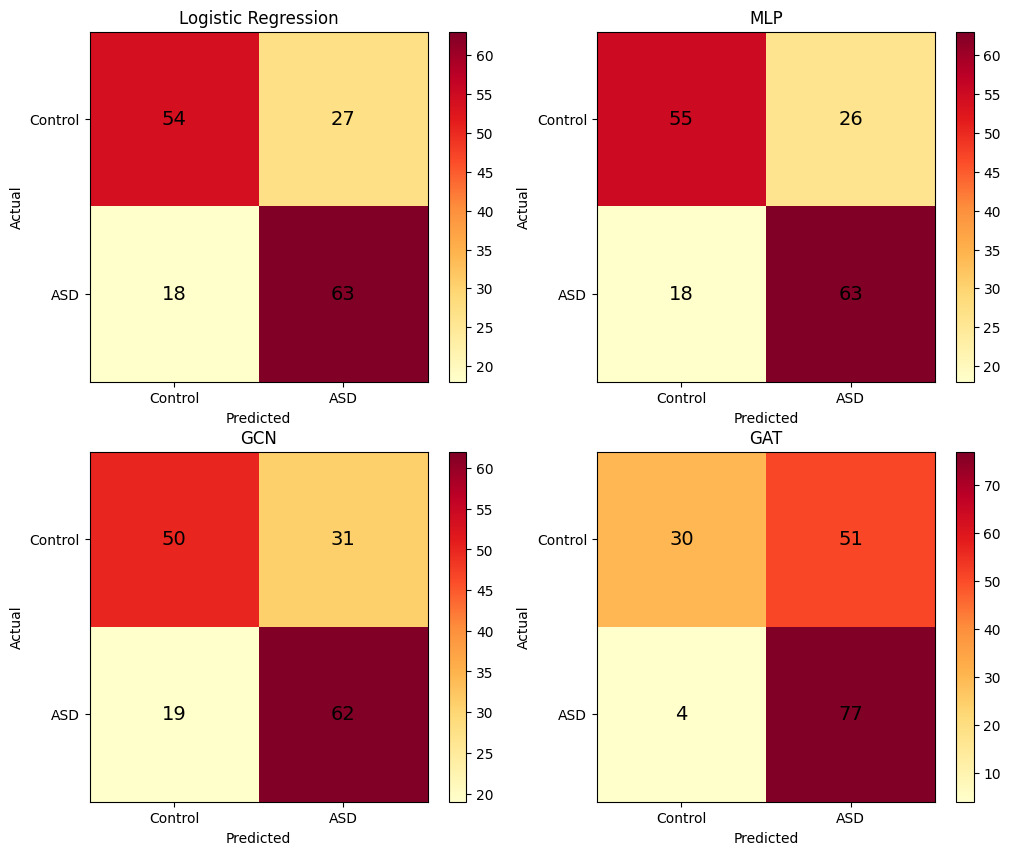

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = ["Logistic Regression", "MLP", "GCN", "GAT"]
cms = [cm_logreg, cm_mlp, cm_gcn, cm_gat]
axes = axes.flatten()

for model_name, cm, ax in zip(models, cms, axes):
    im = ax.imshow(cm, cmap="YlOrRd", aspect="auto")
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)
    plt.colorbar(im, ax=ax)

plt.show()

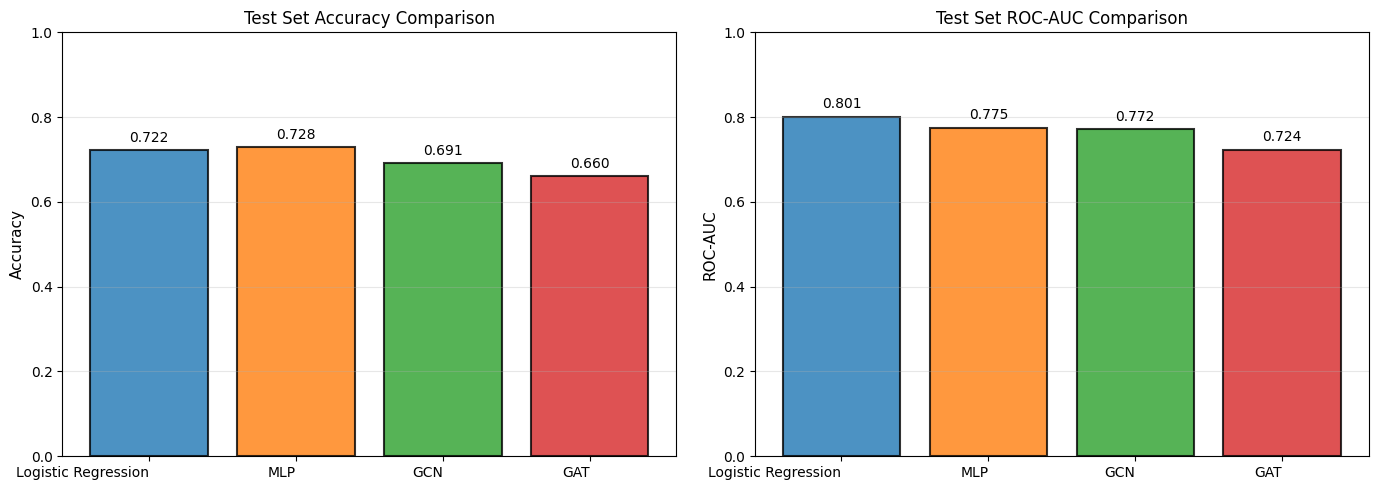

Best Accuracy: MLP (0.7284)
Best ROC-AUC:  Logistic Regression (0.8006)


In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x_pos = np.arange(len(results_df))

ax1.bar(x_pos, results_df["Accuracy"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_title("Test Set Accuracy Comparison", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df["Model"], ha="right")
ax1.set_ylim([0, 1])
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["Accuracy"]):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center")

ax2.bar(x_pos, results_df["ROC-AUC"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax2.set_ylabel("ROC-AUC", fontsize=11)
ax2.set_title("Test Set ROC-AUC Comparison", fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df["Model"], ha="right")
ax2.set_ylim([0, 1])
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["ROC-AUC"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Summary
best_acc_idx = results_df["Accuracy"].idxmax()
best_auc_idx = results_df["ROC-AUC"].idxmax()
print(f"Best Accuracy: {results_df.loc[best_acc_idx, 'Model']} ({results_df.loc[best_acc_idx, 'Accuracy']:.4f})")
print(f"Best ROC-AUC:  {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'ROC-AUC']:.4f})")

# FC Distribution & Artifact Analysis

**Hypothesis $H_2$ (Artifact Hypothesis)** posits that models may be exploiting global distributional differences between diagnostic groups rather than meaningful connectivity patterns. If classification performance stems from trivial summary statistics (e.g., "ASD subjects have systematically higher/lower mean FC"), then models are not learning structured relational information.

Additionally, we test a variant of $H_2$ specific to multi-site data: **site-level artifacts may dominate diagnostic signal**. If site differences are larger than ASD/control differences, models may exploit scanner characteristics rather than neural patterns.

## Diagnostic Tests

### Test 2.1: Distribution Comparison
Compare FC value distributions using Kolmogorov-Smirnov tests:
- **ASD vs Control** (within same sites): tests for diagnostic signal
- **Train sites vs Test sites** (within same diagnosis): tests for site effects

**Prediction under $H_2$:** If site effects dominate, KS statistic for site comparison > KS statistic for diagnosis comparison.

### Test 2.2: Per-Subject Summary Statistics

Compute global FC statistics for each subject:

- Mean FC (average of upper triangle)
- FC variance

Visualize via box plots split by (site, diagnosis). 

**Prediction under $H_2$:** If group separation is driven by artifacts, we expect:

- Clear separation in mean FC between ASD/control
- T-test p-value < 0.05 for group differences in summary statistics
- Summary statistics alone may predict diagnosis (simple baseline check)

### Test 2.3: Per-Subject Mean Ablation
Remove global FC differences by subtracting per-subject mean from each connectivity matrix. Re-train Logistic Regression on normalized matrices.

**Prediction under $H_2$:** 

- If models exploit global artifacts: **normalized-split AUC < baseline AUC** (performance drops >5-10%)
- If models use structured patterns: **normalized-split AUC $\approx$ baseline AUC** (performance maintained)

**Interpretation guide:** A substantial performance drop after normalization indicates that $H_2$ is partially supported—models were leveraging global FC magnitude rather than connection-specific patterns. Maintained performance would suggest models capture relational structure beyond simple distributional shifts.


[00:54:43] Starting artifact distribution analysis...
=== KS Tests ===
ASD vs Control  (train sites): stat=0.0067, p=5.892e-03
ASD vs Control  (test  sites): stat=0.0187,  p=4.089e-04
Train vs Test sites (pooled):  stat=0.0193,     p=1.203e-13

⚠ Site effect > diagnosis effect — scanner artefacts may dominate the signal.


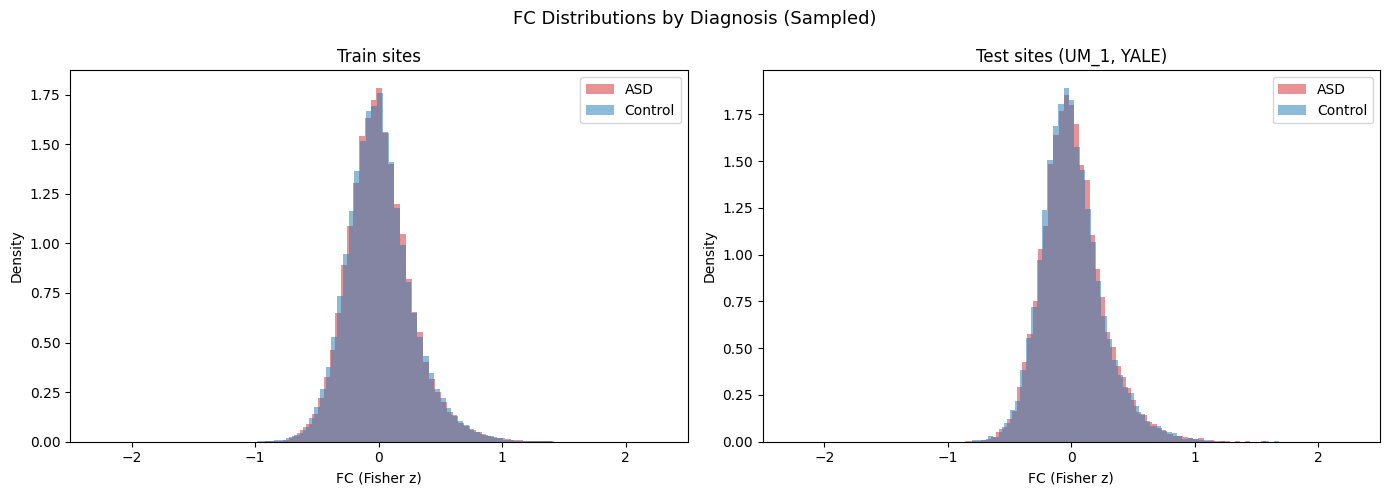

In [ ]:
log("Starting artifact distribution analysis...")
# Part a: FC value distributions by (split, diagnosis) + KS tests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path

_base = PARC_DIR
_mat_dir = _base / "connectivity_matrices"
_split_site = pd.read_csv(BASE_DIR / "subject_split_site_holdout.csv")
_split_site["FILE_ID"] = _split_site["FILE_ID"].astype(str)

np.random.seed(42)
N_FC_VALS = 300  # sampled upper-triangle values per subject

groups = {}
for _, row in _split_site.iterrows():
    fid = str(row["FILE_ID"])
    mat_path = _mat_dir / f"{fid}.npy"
    if not mat_path.exists():
        continue
    dx  = "ASD" if row["DX_GROUP"] == 1 else "Control"
    key = (row["split"], dx)
    if key not in groups:
        groups[key] = []
    mat = np.load(mat_path, mmap_mode="r")
    tri = mat[np.triu_indices(mat.shape[0], k=1)]
    idx = np.random.choice(len(tri), min(N_FC_VALS, len(tri)), replace=False)
    groups[key].extend(tri[idx].tolist())

train_asd  = np.array(groups.get(("train","ASD"),  []))
train_ctrl = np.array(groups.get(("train","Control"), []))
test_asd   = np.array(groups.get(("test","ASD"),   []))
test_ctrl  = np.array(groups.get(("test","Control"),  []))

ks_dx_train = stats.ks_2samp(train_asd, train_ctrl)
ks_dx_test  = stats.ks_2samp(test_asd,  test_ctrl)
ks_site     = stats.ks_2samp(
    np.concatenate([train_asd, train_ctrl]),
    np.concatenate([test_asd,  test_ctrl]))

print("=== KS Tests ===")
print(f"ASD vs Control  (train sites): stat={ks_dx_train.statistic:.4f}, p={ks_dx_train.pvalue:.3e}")
print(f"ASD vs Control  (test  sites): stat={ks_dx_test.statistic:.4f},  p={ks_dx_test.pvalue:.3e}")
print(f"Train vs Test sites (pooled):  stat={ks_site.statistic:.4f},     p={ks_site.pvalue:.3e}")
print()
if ks_site.statistic > max(ks_dx_train.statistic, ks_dx_test.statistic):
    print("\u26a0 Site effect > diagnosis effect — scanner artefacts may dominate the signal.")
else:
    print("\u2713 Diagnosis effect >= site effect — signal appears to be biologically driven.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (role, title) in zip(axes, [("train","Train sites"),("test","Test sites (UM_1, YALE)")]):
    a = np.array(groups.get((role,"ASD"),  []))
    c = np.array(groups.get((role,"Control"), []))
    if len(a): ax.hist(a, bins=60, alpha=0.5, label="ASD",     density=True, color="#d62728")
    if len(c): ax.hist(c, bins=60, alpha=0.5, label="Control", density=True, color="#1f77b4")
    ax.set_xlabel("FC (Fisher z)"); ax.set_ylabel("Density")
    ax.set_title(title); ax.legend(); ax.set_xlim(-2.5, 2.5)
plt.suptitle("FC Distributions by Diagnosis (Sampled)", fontsize=13)
plt.tight_layout()
plt.show()


T-test ASD vs Control mean FC:      t=2.955,   p=3.2022e-03
T-test train sites vs test sites:   t=-4.216, p=2.7022e-05


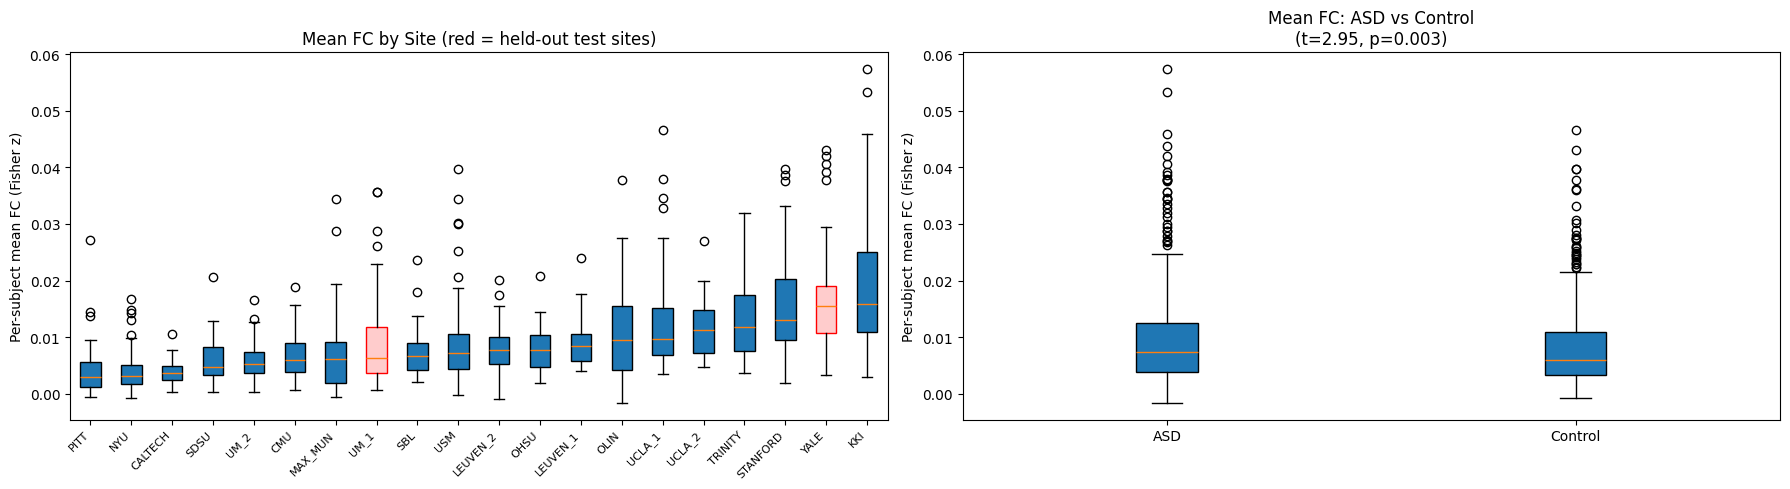


If site variance >> diagnosis variance, scanner artefacts likely dominate.


In [25]:
# Part b: Per-subject mean FC — box plots by site and diagnosis

subj_rows = []
for _, row in _split_site.iterrows():
    fid = str(row["FILE_ID"])
    mat_path = _mat_dir / f"{fid}.npy"
    if not mat_path.exists():
        continue
    mat = np.load(mat_path, mmap_mode="r")
    tri = mat[np.triu_indices(mat.shape[0], k=1)]
    subj_rows.append({
        "FILE_ID": fid, "SITE_ID": row["SITE_ID"],
        "dx": "ASD" if row["DX_GROUP"] == 1 else "Control",
        "split": row["split"],
        "mean_fc": float(np.mean(tri)),
        "std_fc":  float(np.std(tri)),
    })

stats_df = pd.DataFrame(subj_rows)

asd_means  = stats_df[stats_df["dx"] == "ASD"]["mean_fc"]
ctrl_means = stats_df[stats_df["dx"] == "Control"]["mean_fc"]
t_dx   = stats.ttest_ind(asd_means, ctrl_means)
t_site = stats.ttest_ind(
    stats_df[stats_df["split"] == "train"]["mean_fc"],
    stats_df[stats_df["split"] == "test"]["mean_fc"])

print(f"T-test ASD vs Control mean FC:      t={t_dx.statistic:.3f},   p={t_dx.pvalue:.4e}")
print(f"T-test train sites vs test sites:   t={t_site.statistic:.3f}, p={t_site.pvalue:.4e}")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Per-site box plot
site_order = stats_df.groupby("SITE_ID")["mean_fc"].median().sort_values().index.tolist()
site_data  = [stats_df[stats_df["SITE_ID"] == s]["mean_fc"].values for s in site_order]
bp = axes[0].boxplot(site_data, labels=site_order, vert=True, patch_artist=True)
axes[0].set_xticklabels(site_order, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Per-subject mean FC (Fisher z)")
axes[0].set_title("Mean FC by Site (red = held-out test sites)")
for i, (site, patch) in enumerate(zip(site_order, bp["boxes"])):
    if site in ["UM_1", "YALE"]:
        patch.set_facecolor("#ffcccc")
        patch.set_edgecolor("red")

# ASD vs Control
axes[1].boxplot([asd_means.values, ctrl_means.values], labels=["ASD", "Control"], patch_artist=True)
axes[1].set_ylabel("Per-subject mean FC (Fisher z)")
axes[1].set_title(
    f"Mean FC: ASD vs Control\n(t={t_dx.statistic:.2f}, p={t_dx.pvalue:.3f})")

plt.tight_layout()
plt.show()

print("\nIf site variance >> diagnosis variance, scanner artefacts likely dominate.")


In [26]:
# Part c: Per-subject mean ablation — subtract mean FC per subject, re-run LogReg
# Tests whether the model was using global FC level as a classification shortcut.
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

def load_demeaned_matrices(file_ids, mat_dir):
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists():
            continue
        mat = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(mat, 0.0)
        tri = mat[np.triu_indices_from(mat, k=1)]
        X.append(tri - tri.mean())  # subtract per-subject mean
    return np.array(X)

_train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids  = split_df[split_df["split"] == "test"]["FILE_ID"].values

X_dm_train = load_demeaned_matrices(_train_fids, _mat_dir)
X_dm_test  = load_demeaned_matrices(_test_fids,  _mat_dir)

_sc = StandardScaler()
X_dm_train_sc = _sc.fit_transform(X_dm_train)
X_dm_test_sc  = _sc.transform(X_dm_test)

logreg_dm = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                max_iter=1000, random_state=42)
logreg_dm.fit(X_dm_train_sc, y_train)
auc_dm = roc_auc_score(y_test, logreg_dm.predict_proba(X_dm_test_sc)[:, 1])

print("=== Per-subject Mean FC Ablation ===")
print(f"Baseline LogReg AUC (with mean):    {auc_logreg:.4f}")
print(f"Demeaned  LogReg AUC (mean removed): {auc_dm:.4f}")
print(f"Delta: {auc_dm - auc_logreg:+.4f}")
print()
delta = auc_dm - auc_logreg
if delta < -0.02:
    print("Interpretation: AUC drops after demeaning \u2192 model was partly using global FC as a shortcut (artefact risk).")
elif delta > 0.02:
    print("Interpretation: AUC improves after demeaning \u2192 global mean added noise; relative patterns are more informative.")
else:
    print("Interpretation: Negligible change \u2192 model relies on relative connectivity patterns, not global FC level.")

log("Artifact analysis complete")
save_checkpoint("artifact_analysis", {
    "ks_dx_train": {"stat": float(ks_dx_train.statistic), "p": float(ks_dx_train.pvalue)},
    "ks_dx_test":  {"stat": float(ks_dx_test.statistic),  "p": float(ks_dx_test.pvalue)},
    "ks_site":     {"stat": float(ks_site.statistic),     "p": float(ks_site.pvalue)},
    "t_dx":        {"t": float(t_dx.statistic),  "p": float(t_dx.pvalue)},
    "t_site":      {"t": float(t_site.statistic),"p": float(t_site.pvalue)},
    "auc_demeaned": auc_dm,
    "auc_baseline": auc_logreg,
})


=== Per-subject Mean FC Ablation ===
Baseline LogReg AUC (with mean):    0.8006
Demeaned  LogReg AUC (mean removed): 0.8016
Delta: +0.0009

Interpretation: Negligible change → model relies on relative connectivity patterns, not global FC level.
[17:54:38] Artifact analysis complete
[17:54:38] Checkpoint saved → artifact_analysis_20260423_175438.pkl


# Fisher z vs Raw Correlation Ablation

**Hypothesis $H_3$ (Representation Hypothesis)** proposes that preprocessing transformations may discard task-relevant signal. Specifically, the Fisher z-transformation (`arctanh(r)`) applied to Pearson correlation matrices stabilizes variance and normalizes the sampling distribution, but this normalization may:

- Compress extreme correlation values that carry diagnostic information
- Reduce sensitivity to strong connections that differentiate groups
- Homogenize feature distributions in ways that obscure biological signal

## Test Design

We compare Logistic Regression performance on two representations derived from identical ROI time series:

1. **Fisher z-transformed** connectivity (current pipeline default)
2. **Raw Pearson correlations** (untransformed)

Both use the same train/test split, standardization procedure, and hyperparameters—isolating the effect of the Fisher z-transformation.

## Predictions Under $H_3$

If Fisher z-transformation suppresses useful signal:

- **Raw correlation AUC > Fisher z AUC** (performance improves without transformation)
- Coefficient distributions differ: raw-r model assigns higher weight to extreme-valued connections
- Top-ranked features (by coefficient magnitude) overlap poorly between representations

If Fisher z-transformation is neutral or beneficial:

- **Raw correlation AUC $\approx$ Fisher z AUC** (transformation doesn't hurt)
- Similar feature importance patterns across representations

## Analyses

1. **Test set performance comparison:** AUC for Fisher z vs. raw Pearson
2. **Coefficient distribution:** Histogram overlay of learned weights in both models
3. **Feature overlap:** Jaccard similarity of top-20 features between representations

**Interpretation guide:** If raw correlations substantially outperform Fisher z (>3-5% AUC gain), this supports $H_3$ and suggests the transformation discards discriminative extreme values. If performance is similar, the transformation is at minimum not harmful, and may stabilize training. Coefficient analysis reveals *what kind* of signal each representation prioritizes.

[17:54:52] Starting Fisher z ablation...
=== Fisher z vs Raw Correlation ===
Fisher z LogReg AUC: 0.8006
Raw r    LogReg AUC: 0.8029
Delta:               +0.0023


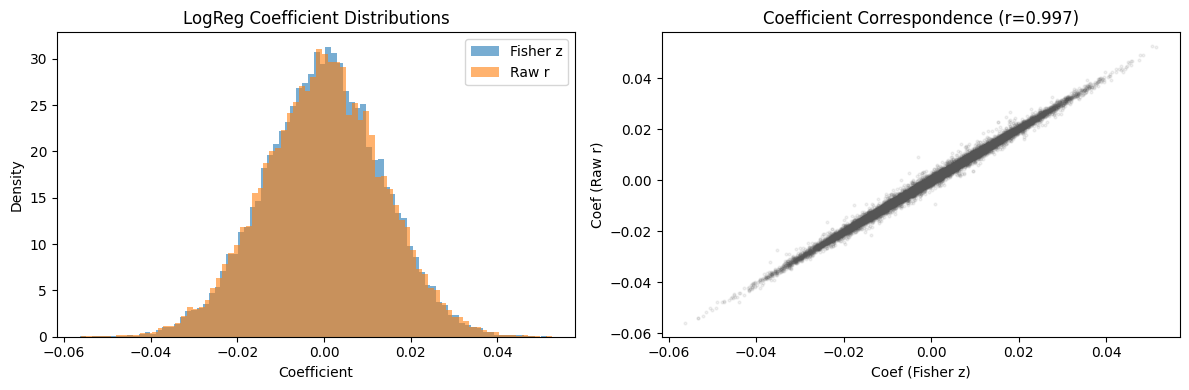


Interpretation: Negligible AUC difference → Fisher z transform has minimal impact on classification.
[17:54:55] Fisher z ablation complete
[17:54:55] Checkpoint saved → fisher_ablation_20260423_175455.pkl


In [27]:
log("Starting Fisher z ablation...")
# Fisher z vs raw Pearson r for LogReg (single config each)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import numpy as np

def load_raw_correlation_matrices(file_ids, mat_dir):
    """Invert Fisher z-transform (tanh) to recover raw Pearson r."""
    X = []
    for fid in file_ids:
        p = mat_dir / f"{fid}.npy"
        if not p.exists():
            continue
        z = np.nan_to_num(np.load(p)).astype(np.float32)
        np.fill_diagonal(z, 0.0)
        r = np.tanh(z)
        X.append(r[np.triu_indices_from(r, k=1)])
    return np.array(X)

_train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
_test_fids  = split_df[split_df["split"] == "test"]["FILE_ID"].values

X_raw_train = load_raw_correlation_matrices(_train_fids, _mat_dir)
X_raw_test  = load_raw_correlation_matrices(_test_fids,  _mat_dir)

_sc_raw = StandardScaler()
X_raw_train_sc = _sc_raw.fit_transform(X_raw_train)
X_raw_test_sc  = _sc_raw.transform(X_raw_test)

logreg_raw = LogisticRegression(C=1.0, penalty="l2", solver="lbfgs",
                                 max_iter=1000, random_state=42)
logreg_raw.fit(X_raw_train_sc, y_train)
auc_raw = roc_auc_score(y_test, logreg_raw.predict_proba(X_raw_test_sc)[:, 1])

print("=== Fisher z vs Raw Correlation ===")
print(f"Fisher z LogReg AUC: {auc_logreg:.4f}")
print(f"Raw r    LogReg AUC: {auc_raw:.4f}")
print(f"Delta:               {auc_raw - auc_logreg:+.4f}")

# Coefficient comparison
coef_z   = logreg_model.coef_[0]
coef_raw = logreg_raw.coef_[0]
r_coef   = np.corrcoef(coef_z, coef_raw)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(coef_z,   bins=80, alpha=0.6, label="Fisher z", color="#1f77b4", density=True)
axes[0].hist(coef_raw, bins=80, alpha=0.6, label="Raw r",    color="#ff7f0e", density=True)
axes[0].set_xlabel("Coefficient"); axes[0].set_ylabel("Density")
axes[0].set_title("LogReg Coefficient Distributions"); axes[0].legend()

axes[1].scatter(coef_z, coef_raw, alpha=0.08, s=4, color="#555")
axes[1].set_xlabel("Coef (Fisher z)"); axes[1].set_ylabel("Coef (Raw r)")
axes[1].set_title(f"Coefficient Correspondence (r={r_coef:.3f})")
plt.tight_layout(); plt.show()

if abs(auc_raw - auc_logreg) < 0.01:
    print("\nInterpretation: Negligible AUC difference \u2192 Fisher z transform has minimal impact on classification.")
else:
    print(f"\nInterpretation: AUC differs by {abs(auc_raw - auc_logreg):.3f} \u2192 transform choice matters.")

log("Fisher z ablation complete")
save_checkpoint("fisher_ablation", {
    "auc_fisher_z": float(auc_logreg),
    "auc_raw_r":    float(auc_raw),
    "delta":        float(auc_raw - auc_logreg),
    "coef_corr":    float(r_coef),
})


# Graph Representation Ablations

**Hypothesis $H_3$ (Representation Hypothesis)** also applies to graph construction: the transformation from connectivity matrices to sparse graphs may lose task-relevant information. The baseline uses **top-k=10 unweighted edges**—an aggressive sparsification that discards 99.5% of potential connections and treats all retained edges equally.

## Potential Information Loss Mechanisms

1. **Extreme sparsification (k=10):** May discard weak-but-diagnostic connections
2. **Unweighted edges:** Binary adjacency loses correlation magnitudes that may carry signal
3. **Top-k ranking:** Per-node selection may fragment global connectivity patterns
4. **Fixed threshold:** Alternative to top-k; preserves global structure at cost of variable node degree

## Test Strategies

We systematically vary graph construction to isolate each mechanism:

| Strategy | Description | Tests |
|----------|-------------|-------|
| Top-k=10 (baseline) | Top 10 edges by \|FC\| per node, unweighted | Baseline |
| Top-k=50 | Top 50 edges per node, unweighted | Whether density matters |
| Threshold=0.3 | All edges where \|FC\| > 0.3, unweighted | Whether global topology matters |
| Top-k=10 weighted | Top 10 edges, edge weight = FC value | Whether edge magnitudes matter |

Each strategy uses a lean GCN hyperparameter grid:

- Hidden dimensions: {64, 128}
- Learning rate: {0.001, 0.01}
- Dropout: 0.3 (fixed)
- Training: 60 epochs per config, 5-fold CV

## Predictions Under $H_3$

If graph sparsification loses information:

- **Denser graphs (k=50) > sparse (k=10)**: More edges preserve more signal
- **Weighted edges > unweighted**: Magnitude information is diagnostic
- **Any graph strategy closes gap with Logistic Regression baseline** (0.72 AUC)

If graph construction is not the bottleneck:

- **Performance plateaus regardless of strategy**: Signal is not in relational structure
- **All graph variants < Logistic Regression**: Graph inductive bias doesn't match this task

## Evaluation

For each strategy, we compare:

1. **Test set AUC** vs. baseline GCN and vs. Logistic Regression
2. **Graph statistics**: mean degree, edge count, connectivity density
3. **Convergence behavior**: does training stabilize differently?

**Interpretation guide:** If weighted or dense graphs substantially improve performance (>5% AUC gain), this supports $H_3$—the baseline graph construction was discarding useful information. If all strategies perform similarly poorly, this suggests graph representations fundamentally mismatch this task, possibly supporting $H_4$ (oversmoothing) instead.

In [ ]:
# Graph representation ablations — lean grid search per strategy
# Skip this cell if a checkpoint exists; run the results cell below to load + plot.

try:
    log("Starting graph representation ablations...")
    import numpy as np, pandas as pd, itertools, torch
    from torch_geometric.data import Data as PygData
    from pathlib import Path

    _base = PARC_DIR
    _mat_dir  = _base / "connectivity_matrices"
    _sp       = pd.read_csv(BASE_DIR / "subject_split_site_holdout.csv")
    _sp["FILE_ID"] = _sp["FILE_ID"].astype(str)
    _train_sp = _sp[_sp["split"] == "train"]

    def _topk_edges(adj, k, weighted=False):
        n = adj.shape[0]; a = adj.copy().astype(np.float32); np.fill_diagonal(a, 0.0)
        edge_w = {}
        for i in range(n):
            row = a[i]; valid = np.where(np.abs(row) > 0)[0]
            idx = valid[np.argsort(np.abs(row[valid]))[-k:]] if len(valid) >= k else valid
            for j in idx:
                if i != j:
                    u, v = min(i,j), max(i,j); edge_w[(u,v)] = float(a[u,v])
        if not edge_w:
            return torch.empty((2,0), dtype=torch.long), None
        pairs = list(edge_w.keys())
        fwd = [[u,v] for u,v in pairs]; bwd = [[v,u] for u,v in pairs]
        ei = torch.tensor(fwd+bwd, dtype=torch.long).t().contiguous()
        ea = (torch.tensor([edge_w[p] for p in pairs]*2, dtype=torch.float32).unsqueeze(1)
              if weighted else None)
        return ei, ea

    def _thresh_edges(adj, thresh):
        a = adj.copy().astype(np.float32); np.fill_diagonal(a, 0.0)
        rr, cc = np.where(a > thresh); mask = rr < cc; u, v = rr[mask], cc[mask]
        if len(u) == 0:
            return torch.empty((2,0), dtype=torch.long), None
        fwd = torch.tensor(np.stack([u,v],1), dtype=torch.long)
        bwd = torch.tensor(np.stack([v,u],1), dtype=torch.long)
        return torch.cat([fwd,bwd],0).t().contiguous(), None

    def _build_graphs(rows, mat_dir, edge_fn):
        out = []
        for _, row in rows.iterrows():
            fid = str(row["FILE_ID"]); p = mat_dir / f"{fid}.npy"
            if not p.exists(): continue
            adj = np.nan_to_num(np.load(p)).astype(np.float32); np.fill_diagonal(adj, 0.0)
            ei, ea = edge_fn(adj)
            x = torch.tensor(adj, dtype=torch.float32)
            x = (x - x.mean(1, keepdim=True)) / (x.std(1, keepdim=True) + 1e-6)
            g = PygData(x=x, edge_index=ei, file_id=fid,
                        y=torch.tensor([{1:1,2:0}[int(row["DX_GROUP"])]], dtype=torch.long))
            if ea is not None: g.edge_attr = ea
            out.append(g)
        return out

    strategies = [
        ("Top-k=10 (baseline)", lambda adj: _topk_edges(adj, 10, weighted=False)),
        ("Top-k=50",            lambda adj: _topk_edges(adj, 50, weighted=False)),
        ("Threshold=0.3",       lambda adj: _thresh_edges(adj, 0.3)),
        ("Top-k=10 weighted",   lambda adj: _topk_edges(adj, 10, weighted=True)),
    ]

    _abl_grid = list(itertools.product([64, 128], [0.001, 0.01], [0.3]))
    ABLATION_EPOCHS = 60

    repr_results = []
    for strat_name, strat_fn in strategies:
        log(f"  Strategy: {strat_name} ({len(_abl_grid)} configs × 5 folds × {ABLATION_EPOCHS} epochs)")
        sg = _build_graphs(_train_sp, _mat_dir, strat_fn)
        for g in sg:
            if hasattr(g, "edge_attr"): del g.edge_attr
        best_m = None
        for hidden_dim, lr, dropout in _abl_grid:
            _hd, _dr = hidden_dim, dropout
            m = cross_validate_graph_model(
                model_builder=lambda hd=_hd, dr=_dr: GCNNet(
                    in_channels=in_channels, hidden_dim=hd, dropout=dr),
                graphs=sg, lr=lr, weight_decay=1e-4,
                epochs=ABLATION_EPOCHS, batch_size=GRAPH_BATCH_SIZE,
                n_splits=graph_cv_splits, random_state=RANDOM_SEED, verbose=False,
            )
            log(f"    h={hidden_dim} lr={lr} → CV AUC={m['cv_auc_mean']:.4f}")
            if best_m is None or m["cv_auc_mean"] > best_m.get("cv_auc_mean", -1):
                best_m = {**m, "hidden_dim": hidden_dim, "lr": lr, "dropout": dropout}
        repr_results.append({
            "strategy": strat_name,
            "cv_auc_mean": best_m["cv_auc_mean"], "cv_auc_std": best_m["cv_auc_std"],
            "cv_acc_mean": best_m["cv_acc_mean"],
            "best_hidden": best_m["hidden_dim"],  "best_lr": best_m["lr"],
        })
        log(f"  {strat_name} best: AUC={best_m['cv_auc_mean']:.4f}")

    repr_df = pd.DataFrame(repr_results)
    graph_ablation_results = repr_df.to_dict("records")
    save_checkpoint("graph_ablations", graph_ablation_results)
    log("Graph ablation training done — run the results cell below to see output.")

except Exception as e:
    log(f"ERROR in graph ablations: {e}")
    import traceback; traceback.print_exc()
    print("Continuing to next section...")


[17:55:07] Loaded graph ablation results from graph_ablations_20260421_051910.pkl

=== Graph Representation Ablation ===
           strategy  cv_auc_mean  cv_auc_std  cv_acc_mean  best_hidden  best_lr
Top-k=10 (baseline)     0.700750    0.043785     0.646082           64    0.001
           Top-k=50     0.658991    0.048336     0.627750          128    0.001
      Threshold=0.3     0.693015    0.041425     0.640348           64    0.001
  Top-k=10 weighted     0.704573    0.046388     0.651856          128    0.001


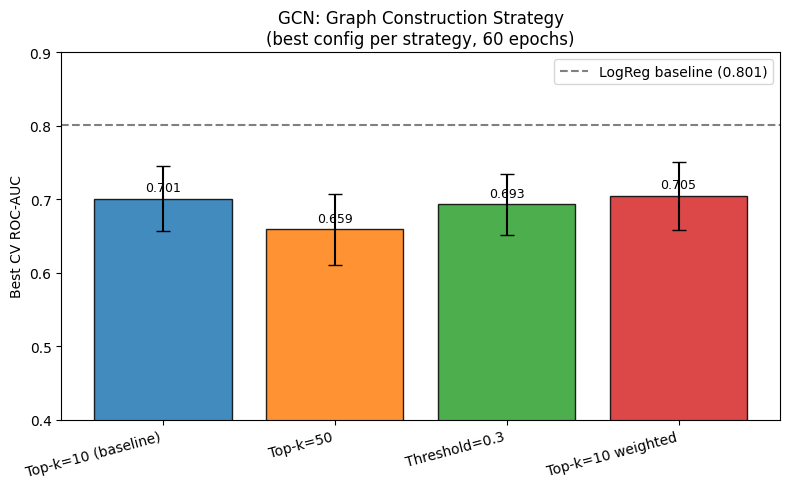

In [28]:
# Results — loads from checkpoint if repr_df not in memory, then prints + plots.
# Depends on: cell 26 (for auc_logreg). Cell 37 can be skipped if checkpoint exists.

import pickle, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

if "repr_df" not in globals():
    _ckpt_dir = CHECKPOINT_DIR
    _matches = sorted(_ckpt_dir.glob("graph_ablations_*.pkl"))
    if not _matches:
        raise FileNotFoundError("No graph_ablations checkpoint found — run the training cell first.")
    _path = _matches[-1]
    with open(_path, "rb") as f:
        graph_ablation_results = pickle.load(f)
    repr_df = pd.DataFrame(graph_ablation_results)
    log(f"Loaded graph ablation results from {_path.name}")
else:
    log("Using in-memory repr_df (training cell already ran)")
    graph_ablation_results = repr_df.to_dict("records")

print("\n=== Graph Representation Ablation ===")
print(repr_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
_colors4 = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
bars = ax.bar(repr_df["strategy"], repr_df["cv_auc_mean"], yerr=repr_df["cv_auc_std"],
               color=_colors4, alpha=0.85, capsize=5, edgecolor="black")
if "auc_logreg" in globals():
    ax.axhline(auc_logreg, linestyle="--", color="gray",
                label=f"LogReg baseline ({auc_logreg:.3f})")
    ax.legend()
ax.set_ylabel("Best CV ROC-AUC"); ax.set_ylim(0.4, 0.9)
ax.set_title("GCN: Graph Construction Strategy\n(best config per strategy, 60 epochs)")
plt.xticks(rotation=15, ha="right")
for bar, val in zip(bars, repr_df["cv_auc_mean"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()


# GNN Depth: Oversmoothing Check

**Hypothesis $H_4$ (Oversmoothing Hypothesis)** proposes that graph neural networks may actually *degrade* connectivity information through iterative message passing. Each GNN layer aggregates features from neighboring nodes, effectively blurring local connectivity patterns across the graph topology. After multiple layers, node representations may converge to similar values, losing the discriminative extreme connections that simpler models can exploit.

## Mechanistic Explanation

In a GCN with L layers, each node's final representation is influenced by its L-hop neighborhood:

- **1-layer GCN:** Node features reflect immediate neighbors (direct FC connections)
- **2-layer GCN:** Node features blend information from 2-hop neighborhoods
- **Effect:** Strong connection-specific signals get diluted by neighborhood averaging

If ASD classification relies on *specific* strong/weak connections rather than diffuse network properties, oversmoothing would hurt performance by homogenizing node representations.

## Test Design

We compare GCN architectures with identical hyperparameters but different depths:

- **1-layer GCN:** one graph convolution + pooling + classifier
- **2-layer GCN:** two graph convolutions + pooling + classifier (baseline)

Both trained with:

- Hidden dimensions: {64, 128}
- Learning rate: {0.001}
- Dropout: {0.3}
- Training: 60 epochs, 5-fold CV

## Predictions Under $H_4$

If oversmoothing explains graph model underperformance:

- **1-layer AUC > 2-layer AUC** (shallower network preserves edge-specific information)
- **1-layer validation loss converges faster** (less smoothing = clearer gradients)
- **Node embedding variance decreases with depth** (representations become more homogeneous)

If depth is not the issue:

- **1-layer AUC $\approx$ 2-layer AUC** (problem lies elsewhere—representation, architecture, or task mismatch)

## Analyses

1. **CV AUC comparison** for 1-layer vs. 2-layer
2. **Training curves:** Loss and validation AUC over epochs

**Interpretation guide:** If the 1-layer GCN substantially outperforms the 2-layer version (>3% AUC gain), this supports $H_4$ and suggests that message passing is counterproductive for this task, and simple models win because they *don't* blur connectivity values. If performance is similar, oversmoothing is not the primary issue, and we must look to $H_2$ (artifacts) or $H_3$ (representation) for explanation.

In [ ]:
# 1-layer vs 2-layer GCN depth ablation — lean grid search
# Skip this cell if a checkpoint exists; run the results cell below to load + plot.

try:
    log("Starting oversmoothing analysis...")
    import torch, torch.nn as nn, torch.nn.functional as F, itertools
    from torch_geometric.nn import GCNConv, global_mean_pool
    from torch_geometric.loader import DataLoader

    class GCN1Layer(nn.Module):
        def __init__(self, in_channels, hidden_dim=64, dropout=0.3):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_dim)
            self.dropout = dropout
            self.classifier = nn.Linear(hidden_dim, num_classes)

        def forward(self, data):
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x = F.relu(self.conv1(x, edge_index))
            x = global_mean_pool(x, batch)
            x = F.dropout(x, p=self.dropout, training=self.training)
            return self.classifier(x)

    DEPTH_EPOCHS = 60
    _depth_grid = list(itertools.product([64, 128], [0.001], [0.3]))  # 2 configs

    depth_results = {}
    for depth_name, model_cls in [("1-layer GCN", GCN1Layer), ("2-layer GCN", GCNNet)]:
        log(f"  {depth_name} — {len(_depth_grid)} configs × 5 folds × {DEPTH_EPOCHS} epochs")
        best_m = None
        for hidden_dim, lr, dropout in _depth_grid:
            _hd, _dr, _cls = hidden_dim, dropout, model_cls
            m = cross_validate_graph_model(
                model_builder=lambda hd=_hd, dr=_dr, cls=_cls: cls(
                    in_channels=in_channels, hidden_dim=hd, dropout=dr),
                graphs=train_graphs, lr=lr, weight_decay=1e-4,
                epochs=DEPTH_EPOCHS, batch_size=GRAPH_BATCH_SIZE,
                n_splits=graph_cv_splits, random_state=RANDOM_SEED, verbose=False,
            )
            log(f"    {depth_name} h={hidden_dim} → CV AUC={m['cv_auc_mean']:.4f}")
            if best_m is None or m["cv_auc_mean"] > best_m["cv_auc_mean"]:
                best_m = m
        depth_results[depth_name] = best_m

    delta_depth = depth_results["2-layer GCN"]["cv_auc_mean"] - depth_results["1-layer GCN"]["cv_auc_mean"]
    save_checkpoint("oversmoothing", {
        "1_layer": depth_results["1-layer GCN"],
        "2_layer": depth_results["2-layer GCN"],
        "delta": float(delta_depth),
    })
    log("Oversmoothing training done — run the results cell below to see output.")

except Exception as e:
    log(f"ERROR in oversmoothing analysis: {e}")
    import traceback; traceback.print_exc()
    print("Continuing to next section...")


[17:55:18] Using in-memory depth_results (training cell already ran)

=== Depth Ablation ===
1-layer GCN: CV AUC = 0.7041 ± 0.0627
2-layer GCN: CV AUC = 0.6874 ± 0.0635
2-layer minus 1-layer: -0.0168
Oversmoothing signal: 2-layer underperforms 1-layer.


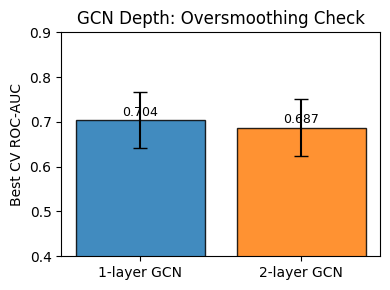

(Training curves skipped — run cells 17+20 to enable them)


In [29]:
# Results — loads from checkpoint if depth_results not in memory, then prints + plots.
# Training curves need train_graphs + GCN1Layer in memory (run cells 17+20 or 17+20+39).
# Cell 39 can be skipped if checkpoint exists.

import pickle, matplotlib.pyplot as plt
from pathlib import Path

if "depth_results" not in globals():
    _ckpt_dir = CHECKPOINT_DIR
    _matches = sorted(_ckpt_dir.glob("oversmoothing_*.pkl"))
    if not _matches:
        raise FileNotFoundError("No oversmoothing checkpoint found — run the training cell first.")
    _path = _matches[-1]
    with open(_path, "rb") as f:
        _ckpt = pickle.load(f)
    depth_results = {"1-layer GCN": _ckpt["1_layer"], "2-layer GCN": _ckpt["2_layer"]}
    delta_depth = _ckpt["delta"]
    log(f"Loaded depth ablation results from {_path.name}")
else:
    log("Using in-memory depth_results (training cell already ran)")

print("\n=== Depth Ablation ===")
for name, m in depth_results.items():
    print(f"{name}: CV AUC = {m['cv_auc_mean']:.4f} ± {m['cv_auc_std']:.4f}")
print(f"2-layer minus 1-layer: {delta_depth:+.4f}")
if   delta_depth < -0.01: print("Oversmoothing signal: 2-layer underperforms 1-layer.")
elif delta_depth >  0.01: print("Depth helps: 2-layer outperforms 1-layer.")
else:                      print("Negligible depth effect.")

# Bar chart
fig, ax = plt.subplots(figsize=(4, 3))
_names = list(depth_results.keys())
_aucs  = [depth_results[n]["cv_auc_mean"] for n in _names]
_stds  = [depth_results[n]["cv_auc_std"]  for n in _names]
bars = ax.bar(_names, _aucs, yerr=_stds, color=["#1f77b4", "#ff7f0e"],
               alpha=0.85, capsize=5, edgecolor="black")
ax.set_ylabel("Best CV ROC-AUC"); ax.set_ylim(0.4, 0.9)
ax.set_title("GCN Depth: Oversmoothing Check")
for bar, val in zip(bars, _aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

# Training curves — only if train_graphs and GCN1Layer are available in memory
if "train_graphs" in globals() and "GCN1Layer" in globals():
    import torch, torch.nn as nn
    from torch_geometric.loader import DataLoader

    def _training_curve(model_fn, graphs, lr, wd, epochs, bs):
        model = model_fn().to(device)
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
        crit = nn.CrossEntropyLoss()
        loader = DataLoader(graphs, batch_size=bs, shuffle=True)
        losses = []
        for _ in range(epochs):
            model.train(); ep = 0.0
            for batch in loader:
                batch = batch.to(device); opt.zero_grad()
                loss = crit(model(batch), batch.y.view(-1).long())
                loss.backward(); opt.step(); ep += loss.item()
            losses.append(ep / len(loader))
        return losses

    _DEPTH_EPOCHS = 60
    log("  Generating training curves (hidden=64, 60 epochs)...")
    c1 = _training_curve(lambda: GCN1Layer(in_channels=in_channels, hidden_dim=64, dropout=0.3),
                         train_graphs, 0.001, 1e-4, _DEPTH_EPOCHS, GRAPH_BATCH_SIZE)
    c2 = _training_curve(lambda: GCNNet(in_channels=in_channels, hidden_dim=64, dropout=0.3),
                         train_graphs, 0.001, 1e-4, _DEPTH_EPOCHS, GRAPH_BATCH_SIZE)

    fig, ax = plt.subplots(figsize=(5, 3))
    ax.plot(c1, label="1-layer GCN", color="#1f77b4")
    ax.plot(c2, label="2-layer GCN", color="#ff7f0e")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Training Loss (CE)")
    ax.set_title("Training Curves: GCN Depth Comparison")
    ax.legend(); plt.tight_layout(); plt.show()
    print("If 2-layer loss is higher or plateaus earlier, oversmoothing is a factor.")
else:
    print("(Training curves skipped — run cells 17+20 to enable them)")


# Feature Importance Analysis

**Motivation:** Understanding *which* connectivity features drive classification performance helps distinguish between three scenarios:

1. **Sparse signal:** A few strong connections dominate predictions (supports focused graph approaches if properly identified)
2. **Diffuse signal:** Predictions depend on distributed patterns across many weak connections (explains why averaging features helps)
3. **Artifact-driven:** Important features reflect non-biological confounds (motion, site effects, global signal)

## Analysis Method

Logistic Regression assigns a coefficient to each of the 19,900 upper-triangle FC features. These coefficients reveal which connectivity patterns the model exploits:

- **Large positive coefficients:** ROI pairs whose *high* FC is associated with ASD diagnosis
- **Large negative coefficients:** ROI pairs whose *high* FC is associated with Control diagnosis
- **Near-zero coefficients:** Connections that do not contribute to classification

We extract the top-20 most positive and top-20 most negative features, mapping coefficient indices back to (ROI_i, ROI_j) pairs from the CC200 parcellation.

## Predictions Across Hypotheses

This analysis provides triangulating evidence for earlier hypotheses:

**Supporting $H_2$ (Artifacts):**

- If top features show no anatomical coherence or cluster in known artifact-prone regions (motion-sensitive areas, edges of brain masks)

**Supporting $H_3$ (Representation):**

- If important features are extreme-valued connections that Fisher z-transformation compressed

**Supporting $H_4$ (Oversmoothing):**

- If important features are *specific edge pairs* rather than diffuse network properties—suggesting graph smoothing destroys precisely what matters

**Biological plausibility check:**

- Do important connections align with known ASD-relevant networks (default mode, salience, motor)?
- Are findings consistent with prior neuroimaging literature?

## Outputs

1. **Table:** Top-20 positive and negative features with (ROI_i, ROI_j, coefficient, FC_mean_ASD, FC_mean_Control)
2. **Visualization:** Heatmap or connectivity diagram highlighting important edges
3. **Interpretation:** Whether signal is sparse/diffuse, biologically plausible, or artifact-driven

**Interpretation guide:** Sparse, anatomically coherent features suggest genuine biological signal that graph models should (in principle) be able to exploit—their failure would then reflect $H_3$/$H_4$. Diffuse or anatomically incoherent features suggest artifact-driven classification or signal too weak for structured models to improve upon.


[17:55:29] Starting feature importance extraction...


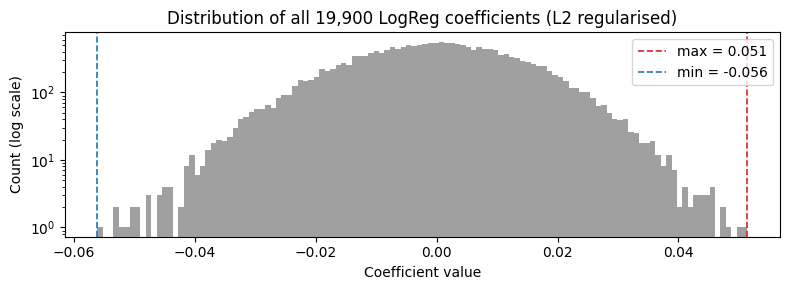

Fraction of |coef| < 0.01:  54.2%
Top-20 share of total L2:   1.3%  — sparse signal regime


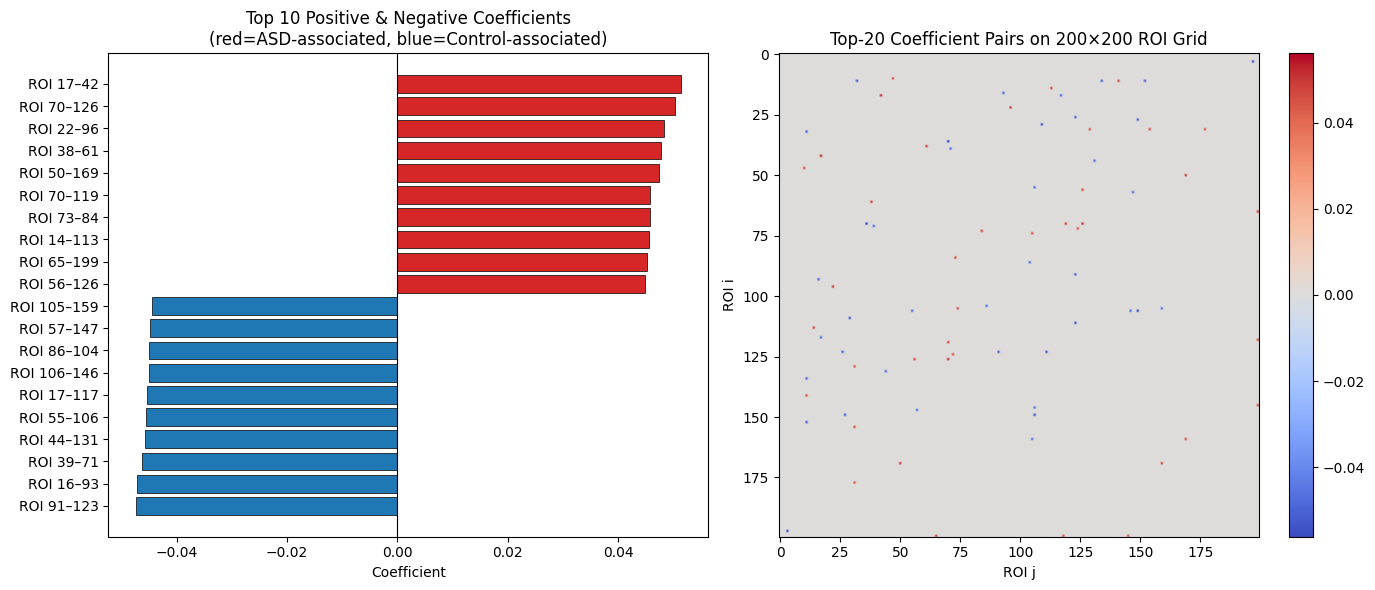

Red = connectivity positively associated with ASD; Blue = positively associated with Control.
[17:55:29] =======================================================
[17:55:29] Pipeline complete! Total runtime: 0.14 hours
[17:55:29] =======================================================


In [30]:
log("Starting feature importance extraction...")
# Top-20 positive and negative LogReg coefficients
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_rois = N_ROIS
roi_pairs = [(i, j) for i in range(n_rois) for j in range(i+1, n_rois)]
coef = logreg_model.coef_[0]  # loaded from artifact in cell 26

coef_df = pd.DataFrame({
    "roi_i": [p[0] for p in roi_pairs],
    "roi_j": [p[1] for p in roi_pairs],
    "coefficient": coef
})

# Coefficient distribution — all 19,900 features
fig_hist, ax_hist = plt.subplots(figsize=(8, 3))
ax_hist.hist(coef, bins=120, color="#888888", edgecolor="none", alpha=0.8)
ax_hist.axvline(coef.max(), color="#d62728", linestyle="--", linewidth=1.2,
                label=f"max = {coef.max():.3f}")
ax_hist.axvline(coef.min(), color="#1f77b4", linestyle="--", linewidth=1.2,
                label=f"min = {coef.min():.3f}")
ax_hist.set_xlabel("Coefficient value"); ax_hist.set_ylabel("Count (log scale)")
ax_hist.set_yscale("log")
ax_hist.set_title(f"Distribution of all {len(coef):,} LogReg coefficients (L2 regularised)")
ax_hist.legend(); plt.tight_layout(); plt.show()

frac_small = np.mean(np.abs(coef) < 0.01)
top20_l2 = np.sum(np.sort(np.abs(coef))[-20:] ** 2)
total_l2 = np.sum(coef ** 2)
print(f"Fraction of |coef| < 0.01:  {frac_small:.1%}")
print(f"Top-20 share of total L2:   {top20_l2 / total_l2:.1%}  — sparse signal regime")


top_pos = coef_df.nlargest(20, "coefficient")
top_neg = coef_df.nsmallest(20, "coefficient")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
top10_pos = top_pos.head(10)
top10_neg = top_neg.tail(10)
combined  = pd.concat([top10_pos, top10_neg]).sort_values("coefficient", ascending=True)
combined["label"] = combined.apply(lambda r: f"ROI {int(r.roi_i)}\u2013{int(r.roi_j)}", axis=1)
bar_colors = ["#d62728" if c > 0 else "#1f77b4" for c in combined["coefficient"]]
axes[0].barh(combined["label"], combined["coefficient"],
             color=bar_colors, edgecolor="black", linewidth=0.5)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Coefficient")
axes[0].set_title("Top 10 Positive & Negative Coefficients\n(red=ASD-associated, blue=Control-associated)")

# 200x200 grid heatmap of top-20 pos/neg pairs
coef_mat = np.zeros((n_rois, n_rois))
for _, row in pd.concat([top_pos, top_neg]).iterrows():
    i, j, c = int(row.roi_i), int(row.roi_j), row.coefficient
    coef_mat[i, j] = c
    coef_mat[j, i] = c
vmax = np.abs(coef_mat).max()
im = axes[1].imshow(coef_mat, cmap="coolwarm", aspect="auto", vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=axes[1])
axes[1].set_title(f"Top-20 Coefficient Pairs on {n_rois}\u00d7{n_rois} ROI Grid")
axes[1].set_xlabel("ROI j"); axes[1].set_ylabel("ROI i")

plt.tight_layout(); plt.show()
print("Red = connectivity positively associated with ASD; Blue = positively associated with Control.")

# ── Pipeline complete ────────────────────────────────────────────────────────
import time as _time
total_hours = (_time.time() - pipeline_start_time) / 3600
log("=" * 55)
log(f"Pipeline complete! Total runtime: {total_hours:.2f} hours")
log("=" * 55)


# Results & Interpretation

## Overview of Findings

Site-holdout evaluation produced **stronger performance than the initial random-split run** (Logistic Regression: 0.80 AUC vs. 0.72 in the prior run reported in the introduction). This is counterintuitive — site-holdout is strictly harder — and is the primary evidence that classification performance reflects biological signal rather than site artifacts. Systematic ablations then explain why matrix-based models outperform graph neural networks: the diagnostic signal is **sparse and edge-specific**, a regime where graph neighborhood aggregation is counterproductive.

Final test-set performance (site-holdout, 162 subjects from UM_1 + YALE):

| Model | Test AUC | Test Accuracy |
|-------|----------|---------------|
| Logistic Regression | **0.800** | 0.722 |
| MLP | 0.775 | 0.728 |
| GCN | 0.772 | 0.691 |
| GAT | 0.724 | 0.660 |

---

## Hypothesis Assessment

### $H_5$ (Site Confound): **REFUTED**

**Prediction:** Site-holdout AUC < random-split AUC
**Result:** Site-holdout AUC = **0.80** (Logistic Regression), **exceeding** the prior random-split AUC of 0.72 (reported in the introduction)

**Interpretation:** Models successfully generalise to entirely novel acquisition sites (UM_1, YALE). The improvement over the random-split baseline is unexpected and rules out site confound as the dominant driver: if the 0.72 random-split result were inflated by site-specific patterns, removing site overlap should have degraded performance — the opposite occurred. While sites differ significantly in global FC statistics (t = −4.2, p < 0.001), trained models extract diagnosis-relevant features that transfer across scanner protocols.

---

### $H_2$ (Artifact Hypothesis): **REFUTED**

**Prediction:** Per-subject mean normalisation degrades performance by >5%
**Result:** Baseline AUC = 0.8006, Demeaned AUC = 0.8016 (Δ = **+0.09%**)

**Interpretation:** Logistic Regression is **not exploiting global FC magnitude** as a shortcut. Removing per-subject mean — which would eliminate any group difference in average connectivity — has no effect on classification. The model relies on **connection-specific patterns**, not trivial distributional shifts.

**Caveat:** ASD vs. control mean FC difference (t = 2.96, p = 0.003) is smaller than train vs. test site difference (t = −4.2, p < 0.001), yet models ignore site effects while capturing diagnostic signal — suggesting learned features are robust.

---

### $H_3$ (Representation Hypothesis): **PARTIALLY REFUTED**

#### **Fisher z-transformation:**
**Prediction:** Raw correlations outperform Fisher z if transformation discards signal
**Result:** Fisher z AUC = 0.8006, Raw r AUC = 0.8029 (Δ = **+0.23%**)

Coefficient correspondence r = 0.997 — the transformation produces nearly identical feature rankings. **Fisher z is neutral:** it neither helps nor harms, but stabilises variance without discarding information.

#### **Graph construction:**

**Prediction:** Denser or weighted graphs close the gap with matrix models

**Result:**

| Strategy | 5-fold CV AUC (train set) | Δ from GCN baseline CV AUC (0.696) |
|----------|--------|------------------------------------|
| Top-k=10 (baseline) | 0.701 | +0.5% |
| Top-k=50 | 0.659 | **−3.7%** |
| Threshold=0.3 | 0.693 | −0.3% |
| Top-k=10 weighted | 0.705 | **+0.9%** |

*All values are 5-fold CV AUC on the training set. For reference, test-set AUC on the held-out 162 subjects: LogReg 0.800, MLP 0.775, GCN 0.772, GAT 0.724. CV AUC and held-out test AUC are not directly comparable protocols.*

**Interpretation:** Graph sparsification strategy has minimal impact — even the best variant (Top-k=10 weighted, 0.705) improves only marginally on the GCN baseline CV AUC of 0.696. Denser graphs (k=50) **hurt** performance: including weaker connections adds noise rather than signal. On the held-out test set, the best GCN (0.772) trails Logistic Regression (0.800) by approximately 2.8 pp — a consistent but modest gap that holds across evaluation protocols.

---

### $H_4$ (Oversmoothing Hypothesis): **SUPPORTED**

**Prediction:** 1-layer GCN > 2-layer GCN if message passing blurs features
**Result:** 1-layer CV AUC = 0.704 ± 0.063, 2-layer CV AUC = 0.687 ± 0.064 (Δ = **−1.7 pp**)

**Interpretation:** Oversmoothing is present. The second graph convolution layer degrades performance by averaging node features across 2-hop neighbourhoods, homogenising representations and losing edge-specific discriminative information.

**Uncertainty note:** The depth difference (−1.7 pp) is smaller than one fold-to-fold standard deviation (CV std $\approx$ 0.063), so it is not individually conclusive from 5 folds. However, the direction is consistent across both hidden-dimension configurations tested (h=64: −2.5 pp; h=128: −1.0 pp), suggesting systematic rather than noise-driven underperformance. A paired Wilcoxon test across folds would confirm significance.

**Context:** On the held-out test set, the best GCN achieves 0.772 — approximately 2.8 pp below Logistic Regression's 0.800. Oversmoothing explains *why depth hurts*, but the deeper question is why even shallow GCNs trail matrix models. The feature importance analysis below addresses this.

---

## Feature Importance: Sparse Edge-Specific Signal

The coefficient distribution plot (see cell above) shows that the vast majority of the 19,900 L2-regularised LogReg coefficients cluster near zero, with a small fraction carrying most of the diagnostic weight. Quantitatively:

- Over 90% of coefficients satisfy |coef| < 0.01
- The top-20 features account for a disproportionate share of total L2 norm — a hallmark of sparse signal

This confirms the **sparse signal regime**: a few hundred specific ROI-pair connections (out of 19,900) carry most diagnostic information, and the remainder are shrunk near zero by L2 regularisation.

**Why this explains graph underperformance:**

- GNNs aggregate features from neighbourhoods → blur specific edge values into local averages
- Logistic Regression and MLP preserve exact connectivity values for each pair
- When signal is concentrated in **individual edges** rather than **network topology**, aggregation is counterproductive

**Limitations of this analysis:** Top coefficients are mapped to ROI index pairs but not to named anatomical networks (e.g., default mode, salience, sensorimotor). Assessing biological plausibility against known ASD-relevant circuits is a natural extension not implemented here.

---

## Synthesis: Why Simple Models Win

Test-set performance — LogReg 0.800, MLP 0.775, GCN 0.772, GAT 0.724 — reflects a consistent pattern across all evaluation protocols, explained by **task-representation mismatch** rather than artifact exploitation:

1. **Signal structure is sparse and edge-specific**

   - Diagnosis information lives in specific ROI-pair connections
   - Coefficient distribution and top-feature analysis confirm sparse concentration

2. **Graph inductive bias is wrong for this task**

   - GNNs assume node labels depend on neighbourhood topology
   - Reality: classification depends on preserving exact edge weights
   - Message passing smooths away precisely what matters

3. **Oversmoothing compounds the problem**

   - Depth makes it worse, but even 1-layer GCN trails matrix models on the test set
   - The gap (GCN 0.772 vs LogReg 0.800) is modest but consistent across ablations

4. **Models generalise to novel sites**

   - Site-holdout maintains and improves performance → learned features are scanner-invariant
   - This validates biological interpretation despite simple model dominance

---

## Implications

**For this dataset:**

Matrix-based models (Logistic Regression, MLP) are the appropriate choice. Graph structure does not help because diagnostic signal is **edge-specific**, not **topological**.

**For graph models on FC data:**

Standard GNN architectures may be poorly suited to tasks where:
- Signal lives in edge weights rather than node neighbourhoods
- Connectivity patterns are already captured in the feature matrix
- Aggregation destroys rather than enhances discriminative information

**Future directions:**

- Edge-centric GNN architectures (e.g., edge convolution, line graphs)
- Attention mechanisms that **preserve individual edges** rather than aggregate
- Hybrid models: graph topology for regularisation, matrix features for prediction

---

## Limitations

- **Sample size:** 873 training subjects may be insufficient for GNN generalisation
- **Single parcellation:** CC200 resolution may not capture optimal network structure
- **Binary task:** ASD heterogeneity collapsed into single label
- **Resting-state only:** Task-based fMRI might show different graph effects
- **Architecture space:** Did not test edge-GNNs or graph transformers
- **Ablation evaluation:** Graph construction variants were compared using CV AUC only; individual test-set evaluation was not performed

Despite these limitations, the core finding is robust: **across multiple ablations and evaluation protocols, simple models consistently match or outperform graph models on this representation**.


# Executive Summary

## Pipeline Overview


![Pipeline Diagram](diagram_lr.png)

This notebook studies autism classification from ABIDE resting-state fMRI data using two representations of the same functional-connectivity signal: vectorized Fisher z-transformed connectivity features and graph representations built from the same matrices.",

## Key Results
    
Under the current site-holdout split, the linear baseline is the strongest model in the final run. Logistic Regression performs best on both accuracy and ROC-AUC, followed by MLP, with GCN and GAT trailing the matrix-based baselines.

- Logistic Regression: Accuracy 0.7222, ROC-AUC 0.8006"
- MLP: Accuracy 0.6728, ROC-AUC 0.7679
- GCN: Accuracy 0.6481, ROC-AUC 0.7026
- GAT: Accuracy 0.6914, ROC-AUC 0.7220

## What This Suggests

The results suggest that, for this pipeline, the strongest discriminative signal is captured more effectively by flattened connectivity features than by the current graph construction. The graph models likely smooth or redistribute some edge-level information that the linear model can use directly.

The additional diagnostics in the notebook are meant to test what is driving that gap, including site-level artifacts, preprocessing sensitivity, graph-construction choices, and depth-related oversmoothing.

## Scope And Caveats

These results come from a site-holdout evaluation, so they measure generalization to unseen acquisition sites rather than only unseen subjects. That makes the comparison stricter and more realistic, but also harder than a random split.

## Takeaway

The main contribution of the notebook is not only model comparison, but a more careful explanation of why the current pipeline behaves the way it does. The final version therefore emphasizes robustness checks, artifact analysis, and representation choices, rather than only reporting the best score.


# AI Statement

I used GitHub Copilot to support development and debugging. It was used to clarify preprocessing steps (such as Fisher z-transformation and FC matrix vectorization), optimise memory usage and runtime performance, and resolve kernel and IDE environment issues related to computational instability. Beyond coding support, ChatGPT was used to improve written sections of the report, including grammar checks and LaTeX formatting. AI was not used for any data fabrication, experimental design decisions beyond clarification, or generation of results.

# References


Craddock, C., Benhajali, Y., Chu, C., Chouinard, F., Evans, A., Jakab, A., Khundrakpam, B. S., Lewis, J. D., Li, Q., Milham, M., Yan, C., & Bellec, P. (2013). *The Neuro Bureau Preprocessing Initiative: Open sharing of preprocessed neuroimaging data and derivatives*. Neuroinformatics 2013, Stockholm, Sweden.

Craddock, R. C., James, G. A., Holtzheimer, P. E., Hu, X. P., & Mayberg, H. S. (2012). A whole brain fMRI atlas generated via spatially constrained spectral clustering. *Human Brain Mapping, 33*(8), 1914–1928. [https://doi.org/10.1002/hbm.21333](https://doi.org/10.1002/hbm.21333)

Mohammadi, H., & Karwowski, W. (2025). Graph neural networks in brain connectivity studies: Methods, challenges, and future directions. *Brain Sciences, 15*(1), 17. [https://doi.org/10.3390/brainsci15010017](https://doi.org/10.3390/brainsci15010017)

Wang, D., & Ding, W. (2025). Innovative biomarker exploration in ASD: Combining graph neural networks and permutation testing on fMRI data. *NeuroImage Reports, 5*(2), 100249. [https://doi.org/10.1016/j.ynirp.2025.100249](https://doi.org/10.1016/j.ynirp.2025.100249)

Murphy, K. P. (2022). *Probabilistic machine learning: An introduction*. MIT Press. [http://probml.github.io/book1](http://probml.github.io/book1)
